Reading CSV files to DataFrame

In [2]:
import pandas as pd
import numpy as np

df=pd.read_csv("cars.csv")
# df.head
# df.head(5)
# df.tail
# df.shape
print(df.dtypes)
print(df)
# df.describe()
# df.info()

Name              object
year               int64
selling_price      int64
km_driven          int64
fuel              object
seller_type       object
transmission      object
owner             object
mileage           object
engine            object
max_power         object
torque            object
seats            float64
dtype: object
                                                Name  year  selling_price  \
0                            Maruti Alto 800 LXI Opt  2023         410000   
1                      Skoda Slavia 1.0 TSI Ambition  2023        1350000   
2      BMW 3 Series Gran Limousine 320Ld Luxury Line  2023        5800000   
3                                 MG ZS EV Exclusive  2023        2650000   
4                               Tata Punch Adventure  2023         715000   
...                                              ...   ...            ...   
8143               Ambassador Classic 2000 DSZ AC PS  1994          99000   
8144                        Mahindra Jeep CL 

Data Cleaning

In [3]:
df.isna() # true false table
df.isna().sum() # sum of all true in each column
df.dropna().isna().sum()
df = df.dropna()

In [4]:
df.dropna(subset=['max_power'], inplace=True)
df.isna().sum()
df['mileage'].mode()[0]
# most frequent value - mode
# df['mileage'].fillna(df['mileage'].mode()[0]).isna().sum()
# df['mileage'] = df['mileage'].fillna(df['mileage'].mode()[0])
# df['engine'].fillna(df['engine'].mode()[0], inplace=True)
# df['torque'].fillna(df['torque'].mode()[0], inplace=True)
# df['seats'].fillna(df['seats'].mode()[0], inplace=True)
df.isna().sum()

# check for duplicates and iqr methods
df.duplicated().sum()
df.value_counts() # counts how many times the row appears
df.drop_duplicates(inplace=True)

IQR method - outlier detedction

In [5]:
dict1={}
for i in df:
    if df[i].dtype=='int64' or df[i].dtype=='float':
        q1=df[i].quantile(0.25)
        q3=df[i].quantile(0.75)
        iqr=q3-q1
        min_range=q1-1.5*iqr
        max_range=q3+1.5*iqr
        dict1[i]=(min_range,max_range)
        # df=df[(df[i]>=min_range) & (df[i]<=max_range) ]
print(dict1)
print(dict1['km_driven'][1])
print(df[df['km_driven']<=dict1['km_driven'][1]])
df=df[df['km_driven']<=dict1['km_driven'][1]]

{'year': (np.float64(2002.0), np.float64(2026.0)), 'selling_price': (np.float64(-350000.0), np.float64(1250000.0)), 'km_driven': (np.float64(-57500.0), np.float64(194500.0)), 'seats': (np.float64(5.0), np.float64(5.0))}
194500.0
                                                Name  year  selling_price  \
0                            Maruti Alto 800 LXI Opt  2023         410000   
1                      Skoda Slavia 1.0 TSI Ambition  2023        1350000   
2      BMW 3 Series Gran Limousine 320Ld Luxury Line  2023        5800000   
3                                 MG ZS EV Exclusive  2023        2650000   
4                               Tata Punch Adventure  2023         715000   
...                                              ...   ...            ...   
8139                                   Maruti 800 AC  1996          42000   
8140                                   Maruti 800 DX  1996          40000   
8142                                  Maruti 800 Std  1995          55000   
8

Vizualise Outliers using box plot

([<matplotlib.axis.YTick at 0x1dc35896120>,
 [Text(0, 0, '0'),
  Text(0, 15000, '15000'),
  Text(0, 30000, '30000'),
  Text(0, 45000, '45000'),
  Text(0, 60000, '60000'),
  Text(0, 75000, '75000'),
  Text(0, 90000, '90000'),
  Text(0, 105000, '105000'),
  Text(0, 120000, '120000'),
  Text(0, 135000, '135000'),
  Text(0, 150000, '150000'),
  Text(0, 165000, '165000'),
  Text(0, 180000, '180000'),
  Text(0, 195000, '195000'),
  Text(0, 210000, '210000'),
  Text(0, 225000, '225000'),
  Text(0, 240000, '240000'),
  Text(0, 255000, '255000'),
  Text(0, 270000, '270000'),
  Text(0, 285000, '285000')])

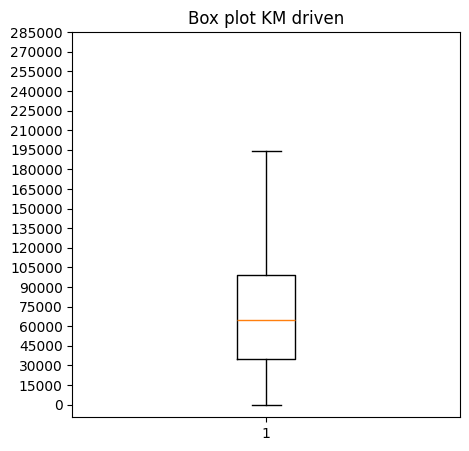

In [6]:
import matplotlib.pyplot as plt
plt.figure(figsize=(5,5))
plt.boxplot(df['km_driven'])
plt.title('Box plot KM driven')
plt.yticks(range(0,300000,15000))

In [7]:
print(df['seats'])

0       5.0
1       5.0
2       5.0
3       5.0
4       5.0
       ... 
8139    4.0
8140    4.0
8142    4.0
8143    5.0
8145    4.0
Name: seats, Length: 6578, dtype: float64


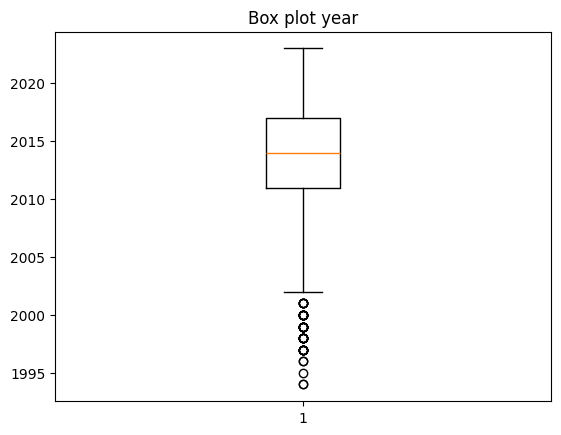

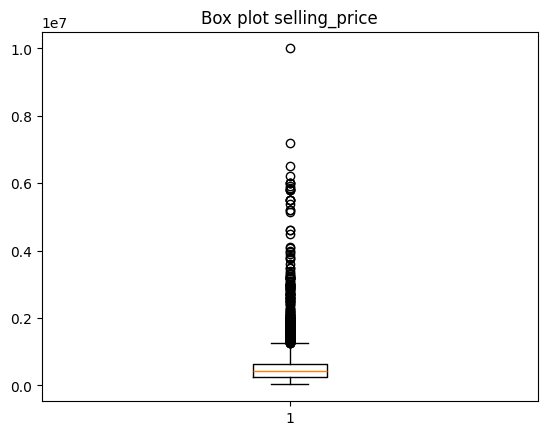

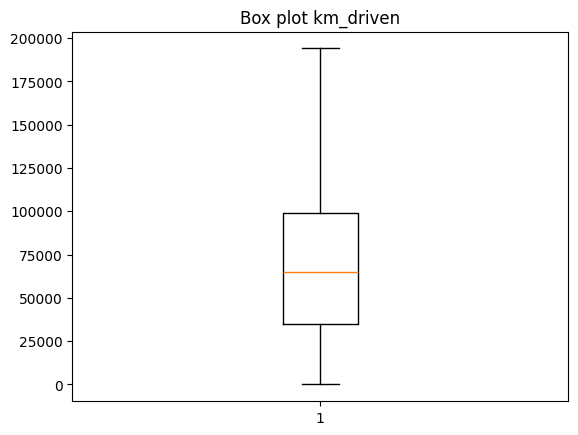

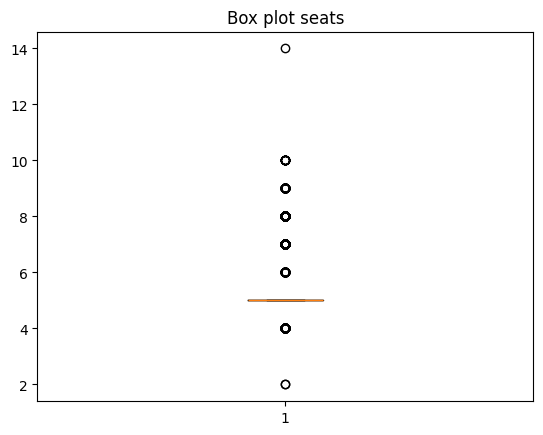

In [8]:
for i in df:
    if df[i].dtype=='int64' or df[i].dtype=='float':
        plt.boxplot(df[i])
        plt.title(f'Box plot {i}')
        # plt.yticks(range(0,300000,15000))
        plt.show()

In [9]:
df['transmission'].unique()
df['transmission'] = df['transmission'].str.strip()
df['transmission'].unique()
df['transmission'].value_counts()

transmission
Manual       6000
Automatic     578
Name: count, dtype: int64

In [10]:
df['mileage']
df['mileage']=df['mileage'].str.strip("kmpl/g ")
df['mileage'] = df['mileage'].astype(float)

In [11]:
df['mileage'].dtype

dtype('float64')

In [12]:
df['engine'] = df['engine'].str.lower().str.strip("c ")
df['engine'] = df['engine'].astype(float)

In [13]:
df['mileage'].dtype

dtype('float64')

In [14]:
df['max_power'] = df['max_power'].str.lower().str.strip("bhp")
df['max_power'].replace('', np.nan)
df['max_power'].dropna()
df['max_power'] = df['max_power'].astype(float)

In [15]:
df['max_power'].dtype

dtype('float64')

In [16]:
df['torque'].str.lower().replacestr.split(" ")
# df['torque'] = df['torque'].str.lower().str.strip("bhp")
# df['max_power'] = df['max_power'].astype(float)

# df['torque'].unique()
# df['torque']=df['torque'].str.lower().replace(['n.+','@.+','k.+','[ ()/]'],'',regex=True)
# df['torque']=df['torque'].astype(float)


AttributeError: 'Series' object has no attribute 'replacestr'

Apply

In [ ]:
# df['engine'].apply(func=lambda x:int(x.split()[0]))
df['engine']

0        999.0
1       1956.0
2        998.0
3        998.0
4       1451.0
         ...  
8139     796.0
8140     796.0
8142     796.0
8143    1995.0
8145     796.0
Name: engine, Length: 7733, dtype: float64

Feature Engineering

In [33]:
df['Company']=df['Name'].apply(func=lambda x:x.strip().split()[0])
len(df.columns)
df=df.iloc[:,[0,-1,1,2,3,4,5,6,7,8,9,10,11,12]]
len(df.columns)
df

,Name,Company,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Alto 800 LXI Opt,Maruti,2023,410000,10000,Petrol,Individual,Manual,First Owner,19.03,999.0,71.01,96Nm,5.0
1,Skoda Slavia 1.0 TSI Ambition,Skoda,2023,1350000,10000,Petrol,Individual,Manual,First Owner,14.08,1956.0,167.67,350nm,5.0
2,BMW 3 Series Gran Limousine 320Ld Luxury Line,BMW,2023,5800000,1000,Diesel,Dealer,Automatic,First Owner,18.15,998.0,118.35,172Nm,5.0
3,MG ZS EV Exclusive,MG,2023,2650000,10000,Electric,Dealer,Automatic,First Owner,32.52,998.0,58.33,78Nm,5.0
4,Tata Punch Adventure,Tata,2023,715000,10000,Petrol,Individual,Manual,First Owner,12.15,1451.0,141.00,250Nm,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8139,Maruti 800 AC,Maruti,1996,42000,70000,Petrol,Individual,Manual,Third Owner,16.10,796.0,37.00,59Nm@ 2500rpm,4.0
8140,Maruti 800 DX,Maruti,1996,40000,32000,Petrol,Individual,Manual,Second Owner,16.10,796.0,37.00,59Nm@ 2500rpm,4.0
8142,Maruti 800 Std,Maruti,1995,55000,70000,Petrol,Individual,Manual,First Owner,16.10,796.0,37.00,59Nm@ 2500rpm,4.0
8143,Ambassador Classic 2000 DSZ AC PS,Ambassador,1994,99000,100000,Diesel,Individual,Manual,Second Owner,12.80,1995.0,52.00,106Nm@ 2200rpm,5.0


In [34]:
def mileage_category(mileage):
    if mileage<12:
        return 'low'
    elif mileage>=12 and mileage<20:
        return 'medium'
    else:
        return 'high'
df['mileage_category'] = df['mileage'].apply(func=mileage_category)
df = df.loc[:,['Name', 'Company', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'mileage', 'mileage_category', 'engine', 'max_power', 'torque', 'seats']]
df.describe()

,year,selling_price,km_driven,mileage,engine,max_power,seats
count,6578.000000,6.578000e+03,6578.000000,6578.000000,6578.000000,6578.000000,6578.000000
mean,2013.720432,5.317979e+05,68517.003497,19.552741,1417.374430,87.742415,5.406811
std,3.894864,5.341300e+05,39862.620330,4.023896,483.195518,32.012047,0.954760
min,1994.000000,2.999900e+04,1.000000,0.000000,624.000000,32.800000,2.000000
25%,2011.000000,2.500000e+05,35000.000000,16.960000,1197.000000,67.100000,5.000000
50%,2014.000000,4.200000e+05,65000.000000,19.670000,1248.000000,81.830000,5.000000
75%,2017.000000,6.500000e+05,99270.750000,22.540000,1498.000000,99.000000,5.000000
max,2023.000000,1.000000e+07,194000.000000,42.000000,3604.000000,400.000000,14.000000


In [36]:
def price_category(selling_price):
    if selling_price<250000:
        return 'cheap'
    elif selling_price>=250000 and selling_price<650000:
        return 'economic'
    elif selling_price>=650000 and selling_price<1300000:
        return 'premium'
    else:
        return 'luxury'
df['price_category'] = df['selling_price'].apply(func=price_category)
df = df.loc[:,['Name', 'Company', 'year', 'selling_price', 'price_category', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'mileage', 'mileage_category', 'engine', 'max_power', 'torque', 'seats']]
df

,Name,Company,year,selling_price,price_category,km_driven,fuel,seller_type,transmission,owner,mileage,mileage_category,engine,max_power,torque,seats
0,Maruti Alto 800 LXI Opt,Maruti,2023,410000,economic,10000,Petrol,Individual,Manual,First Owner,19.03,medium,999.0,71.01,96Nm,5.0
1,Skoda Slavia 1.0 TSI Ambition,Skoda,2023,1350000,luxury,10000,Petrol,Individual,Manual,First Owner,14.08,medium,1956.0,167.67,350nm,5.0
2,BMW 3 Series Gran Limousine 320Ld Luxury Line,BMW,2023,5800000,luxury,1000,Diesel,Dealer,Automatic,First Owner,18.15,medium,998.0,118.35,172Nm,5.0
3,MG ZS EV Exclusive,MG,2023,2650000,luxury,10000,Electric,Dealer,Automatic,First Owner,32.52,high,998.0,58.33,78Nm,5.0
4,Tata Punch Adventure,Tata,2023,715000,premium,10000,Petrol,Individual,Manual,First Owner,12.15,medium,1451.0,141.00,250Nm,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8139,Maruti 800 AC,Maruti,1996,42000,cheap,70000,Petrol,Individual,Manual,Third Owner,16.10,medium,796.0,37.00,59Nm@ 2500rpm,4.0
8140,Maruti 800 DX,Maruti,1996,40000,cheap,32000,Petrol,Individual,Manual,Second Owner,16.10,medium,796.0,37.00,59Nm@ 2500rpm,4.0
8142,Maruti 800 Std,Maruti,1995,55000,cheap,70000,Petrol,Individual,Manual,First Owner,16.10,medium,796.0,37.00,59Nm@ 2500rpm,4.0
8143,Ambassador Classic 2000 DSZ AC PS,Ambassador,1994,99000,cheap,100000,Diesel,Individual,Manual,Second Owner,12.80,medium,1995.0,52.00,106Nm@ 2200rpm,5.0


In [40]:
def engine_category(engine):
    if engine<1200:
        return 'low_power'
    elif engine>=1200 and engine<1500:
        return 'medium_power'
    else:
        return 'high_power'
df['engine_category'] = df['engine'].apply(func=engine_category)
df = df.loc[:,['Name', 'Company', 'year', 'selling_price', 'price_category', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'mileage', 'mileage_category', 'engine', 'engine_category', 'max_power', 'torque', 'seats']]
df

,Name,Company,year,selling_price,price_category,km_driven,fuel,seller_type,transmission,owner,mileage,mileage_category,engine,engine_category,max_power,torque,seats
0,Maruti Alto 800 LXI Opt,Maruti,2023,410000,Economic,10000,Petrol,Individual,Manual,First Owner,19.03,medium,999.0,low_power,71.01,96Nm,5.0
1,Skoda Slavia 1.0 TSI Ambition,Skoda,2023,1350000,Luxury,10000,Petrol,Individual,Manual,First Owner,14.08,medium,1956.0,high_power,167.67,350nm,5.0
2,BMW 3 Series Gran Limousine 320Ld Luxury Line,BMW,2023,5800000,Luxury,1000,Diesel,Dealer,Automatic,First Owner,18.15,medium,998.0,low_power,118.35,172Nm,5.0
3,MG ZS EV Exclusive,MG,2023,2650000,Luxury,10000,Electric,Dealer,Automatic,First Owner,32.52,high,998.0,low_power,58.33,78Nm,5.0
4,Tata Punch Adventure,Tata,2023,715000,Premium,10000,Petrol,Individual,Manual,First Owner,12.15,medium,1451.0,medium_power,141.00,250Nm,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8139,Maruti 800 AC,Maruti,1996,42000,Cheap,70000,Petrol,Individual,Manual,Third Owner,16.10,medium,796.0,low_power,37.00,59Nm@ 2500rpm,4.0
8140,Maruti 800 DX,Maruti,1996,40000,Cheap,32000,Petrol,Individual,Manual,Second Owner,16.10,medium,796.0,low_power,37.00,59Nm@ 2500rpm,4.0
8142,Maruti 800 Std,Maruti,1995,55000,Cheap,70000,Petrol,Individual,Manual,First Owner,16.10,medium,796.0,low_power,37.00,59Nm@ 2500rpm,4.0
8143,Ambassador Classic 2000 DSZ AC PS,Ambassador,1994,99000,Cheap,100000,Diesel,Individual,Manual,Second Owner,12.80,medium,1995.0,high_power,52.00,106Nm@ 2200rpm,5.0


In [38]:
df['price_category'] = pd.cut(df['selling_price'], bins=[0, 250000, 650000, 1300000, 10000000], labels=['Cheap', 'Economic', 'Premium', 'Luxury'])
df = df.loc[:,['Name', 'Company', 'year', 'selling_price', 'price_category', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'mileage', 'mileage_category', 'engine', 'max_power', 'torque', 'seats']]
df

,Name,Company,year,selling_price,price_category,km_driven,fuel,seller_type,transmission,owner,mileage,mileage_category,engine,max_power,torque,seats
0,Maruti Alto 800 LXI Opt,Maruti,2023,410000,Economic,10000,Petrol,Individual,Manual,First Owner,19.03,medium,999.0,71.01,96Nm,5.0
1,Skoda Slavia 1.0 TSI Ambition,Skoda,2023,1350000,Luxury,10000,Petrol,Individual,Manual,First Owner,14.08,medium,1956.0,167.67,350nm,5.0
2,BMW 3 Series Gran Limousine 320Ld Luxury Line,BMW,2023,5800000,Luxury,1000,Diesel,Dealer,Automatic,First Owner,18.15,medium,998.0,118.35,172Nm,5.0
3,MG ZS EV Exclusive,MG,2023,2650000,Luxury,10000,Electric,Dealer,Automatic,First Owner,32.52,high,998.0,58.33,78Nm,5.0
4,Tata Punch Adventure,Tata,2023,715000,Premium,10000,Petrol,Individual,Manual,First Owner,12.15,medium,1451.0,141.00,250Nm,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8139,Maruti 800 AC,Maruti,1996,42000,Cheap,70000,Petrol,Individual,Manual,Third Owner,16.10,medium,796.0,37.00,59Nm@ 2500rpm,4.0
8140,Maruti 800 DX,Maruti,1996,40000,Cheap,32000,Petrol,Individual,Manual,Second Owner,16.10,medium,796.0,37.00,59Nm@ 2500rpm,4.0
8142,Maruti 800 Std,Maruti,1995,55000,Cheap,70000,Petrol,Individual,Manual,First Owner,16.10,medium,796.0,37.00,59Nm@ 2500rpm,4.0
8143,Ambassador Classic 2000 DSZ AC PS,Ambassador,1994,99000,Cheap,100000,Diesel,Individual,Manual,Second Owner,12.80,medium,1995.0,52.00,106Nm@ 2200rpm,5.0


In [ ]:
df.reset_index(drop=True, inplace=True)
df

,Name,Company,year,selling_price,price_category,km_driven,fuel,seller_type,transmission,owner,mileage,mileage_category,engine,max_power,torque,seats
0,Maruti Alto 800 LXI Opt,Maruti,2023,410000,economy,10000,Petrol,Individual,Manual,First Owner,19.03,medium,999.0,71.01,96Nm,5.0
1,Skoda Slavia 1.0 TSI Ambition,Skoda,2023,1350000,luxury,10000,Petrol,Individual,Manual,First Owner,14.08,medium,1956.0,167.67,350nm,5.0
2,BMW 3 Series Gran Limousine 320Ld Luxury Line,BMW,2023,5800000,luxury,1000,Diesel,Dealer,Automatic,First Owner,18.15,medium,998.0,118.35,172Nm,5.0
3,MG ZS EV Exclusive,MG,2023,2650000,luxury,10000,Electric,Dealer,Automatic,First Owner,32.52,high,998.0,58.33,78Nm,5.0
4,Tata Punch Adventure,Tata,2023,715000,economy,10000,Petrol,Individual,Manual,First Owner,12.15,medium,1451.0,141.00,250Nm,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6573,Maruti 800 AC,Maruti,1996,42000,cheap,70000,Petrol,Individual,Manual,Third Owner,16.10,medium,796.0,37.00,59Nm@ 2500rpm,4.0
6574,Maruti 800 DX,Maruti,1996,40000,cheap,32000,Petrol,Individual,Manual,Second Owner,16.10,medium,796.0,37.00,59Nm@ 2500rpm,4.0
6575,Maruti 800 Std,Maruti,1995,55000,cheap,70000,Petrol,Individual,Manual,First Owner,16.10,medium,796.0,37.00,59Nm@ 2500rpm,4.0
6576,Ambassador Classic 2000 DSZ AC PS,Ambassador,1994,99000,cheap,100000,Diesel,Individual,Manual,Second Owner,12.80,medium,1995.0,52.00,106Nm@ 2200rpm,5.0


Analysis

In [31]:
dict1={}
for i in df:
    if df[i].dtype=='object' and df[i].nunique()<100:
        print(i)
        dict1[i]=[]
        print('===========================')
        print(f'Number of unique categories {df[i].unique()}')
        print(f'Number of number of unique categories {df[i].nunique()}')
        print(f'Number of entries in categories {df[i].value_counts}')
        dict1[i].append(df[i].unique())
        dict1[i].append(df[i].nunique())
        dict1[i].append(df[i].value_counts)
        print(f"Mode value : {df[i].mode()[0]}")
        print('**************************************')
        print()

fuel
Number of unique categories ['Petrol' 'Diesel' 'Electric' 'CNG' 'LPG']
Number of number of unique categories 5
Number of entries in categories <bound method IndexOpsMixin.value_counts of 0         Petrol
1         Petrol
2         Diesel
3       Electric
4         Petrol
          ...   
8139      Petrol
8140      Petrol
8142      Petrol
8143      Diesel
8145      Petrol
Name: fuel, Length: 6578, dtype: object>
Mode value : Diesel
**************************************

seller_type
Number of unique categories ['Individual' 'Dealer' 'Trustmark Dealer']
Number of number of unique categories 3
Number of entries in categories <bound method IndexOpsMixin.value_counts of 0       Individual
1       Individual
2           Dealer
3           Dealer
4       Individual
           ...    
8139    Individual
8140    Individual
8142    Individual
8143    Individual
8145    Individual
Name: seller_type, Length: 6578, dtype: object>
Mode value : Individual
**************************************



In [42]:
# convert to categorical type for columns that are objects
df.dtypes
df_categorical = [
'Name',
'Company',
'price_category',
'fuel',
'seller_type',
'transmission',
'owner',
'mileage_category',
'engine_category',
'torque'
]
for i in df_categorical:
    df[i]=df[i].astype('category')
df.dtypes

Name                category
Company             category
year                   int64
selling_price          int64
price_category      category
km_driven              int64
fuel                category
seller_type         category
transmission        category
owner               category
mileage              float64
mileage_category    category
engine               float64
engine_category     category
max_power            float64
torque              category
seats                float64
dtype: object

In [45]:
dict2={}
for i in df:
    if df[i].dtype=='int64' or df[i].dtype=='float':
        print(i)
        dict2[i]=[]
        print('===========================')
        print(f'Mean {df[i].mean()}')
        print(f'Median {df[i].median()}')
        print(f'Mode {df[i].mode()[0]}')
        print(f'Min {df[i].min()}')
        print(f'Max {df[i].max()}')
        print(f'STD {df[i].std()}')
        print(f'Variance {df[i].var()}')
        dict2[i].append(df[i].mean())
        dict2[i].append(df[i].median())
        dict2[i].append(df[i].mode())
        dict2[i].append(df[i].min())
        dict2[i].append(df[i].max())
        dict2[i].append(df[i].std())
        dict2[i].append(df[i].var())
        print('**************************************')
        print()

year
Mean 2013.7204317421708
Median 2014.0
Mode 2017
Min 1994
Max 2023
STD 3.894864202292965
Variance 15.169967154303215
**************************************

selling_price
Mean 531797.9253572514
Median 420000.0
Mode 300000
Min 29999
Max 10000000
STD 534129.9756821872
Variance 285294830922.25397
**************************************

km_driven
Mean 68517.0034965035
Median 65000.0
Mode 120000
Min 1
Max 194000
STD 39862.620329783545
Variance 1589028499.5564723
**************************************

mileage
Mean 19.552740954697477
Median 19.67
Mode 18.9
Min 0.0
Max 42.0
STD 4.023896180498292
Variance 16.191740471428737
**************************************

engine
Mean 1417.3744299179082
Median 1248.0
Mode 1248.0
Min 624.0
Max 3604.0
STD 483.1955182857732
Variance 233477.90889145696
**************************************

max_power
Mean 87.74241486774095
Median 81.83
Mode 74.0
Min 32.8
Max 400.0
STD 32.01204737504754
Variance 1024.7711771422878
**************************************


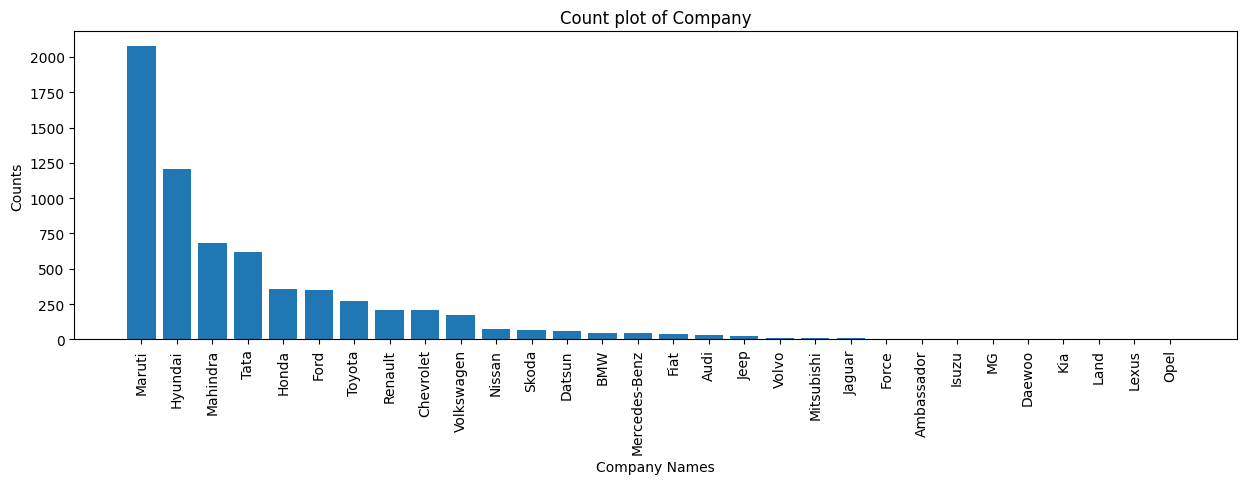

In [63]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15,4))
plt.bar(df['Company'].value_counts().index, df['Company'].value_counts())
plt.title("Count plot of Company")
plt.xlabel("Company Names")
plt.ylabel("Counts")
plt.xticks(rotation=90)
plt.show()

<Axes: xlabel='Company'>

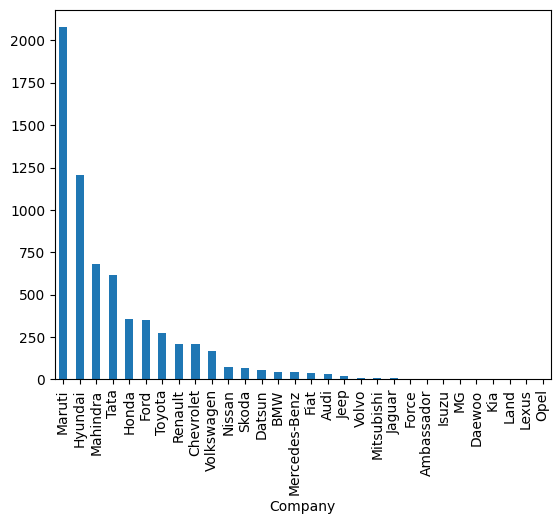

In [82]:
df['Company'].value_counts().plot(kind='bar')

Univariate Analysis of categorical columns

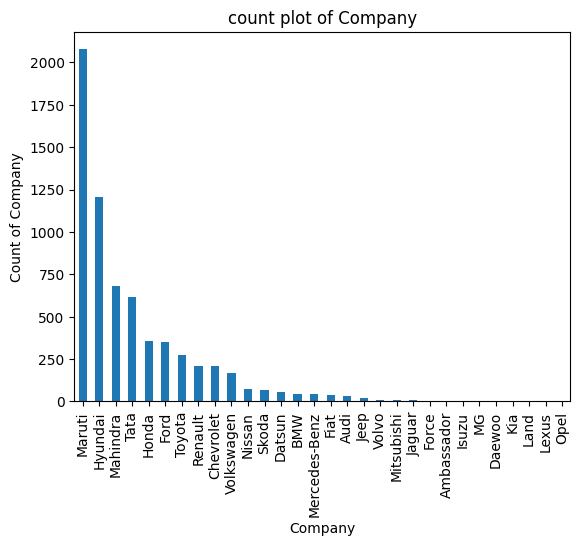

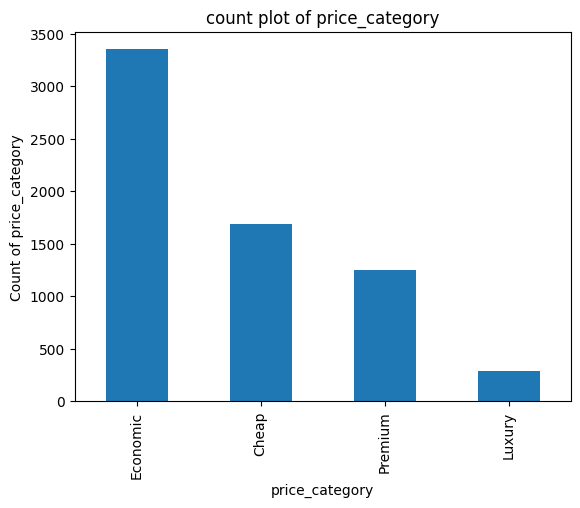

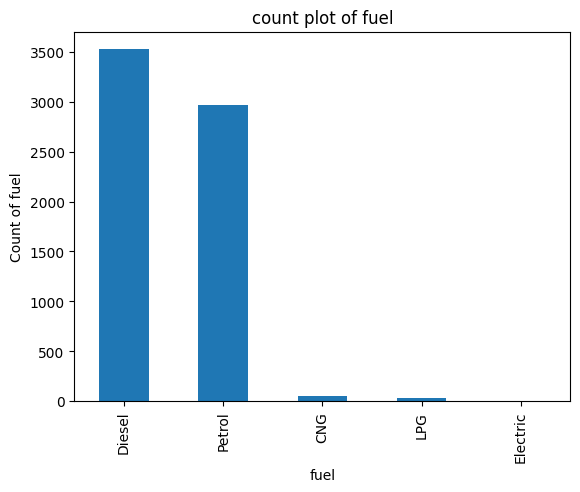

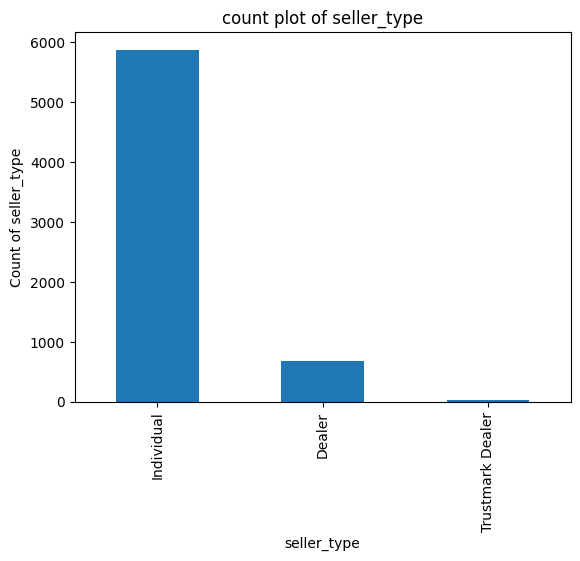

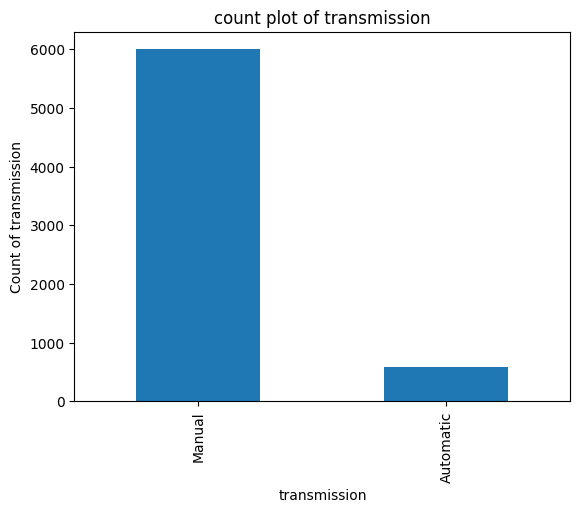

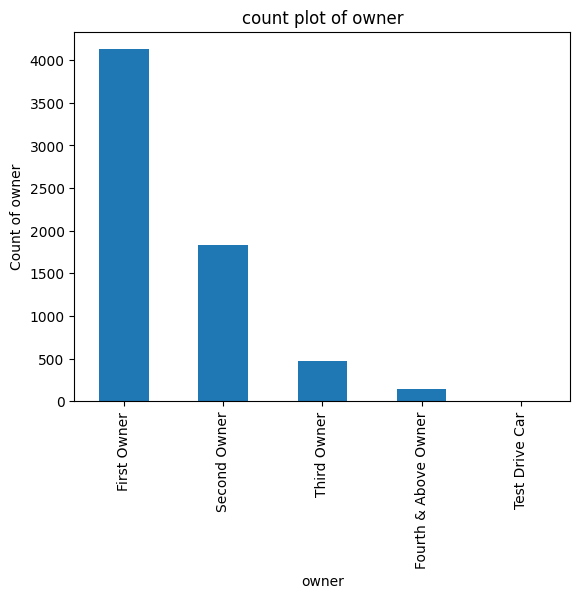

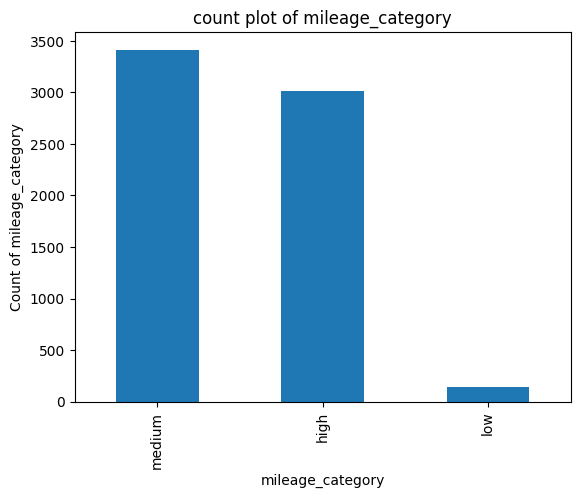

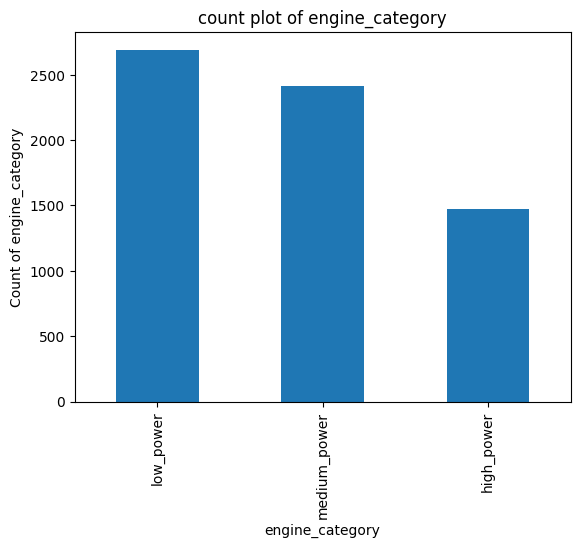

In [81]:
for i in df:
    if df[i].dtype == 'category':
        df[i].value_counts().plot(kind='bar')
        plt.title(f"count plot of {i}")
        plt.xlabel(i)
        plt.ylabel(f'Count of {i}')
        plt.show()
# df['torque'] = df['torque'].astype('object')
# df['Name'] = df['Name'].astype('object')
# df.dtypes


Univariate Analysis of Numerical columns

In [115]:
dict2={}
for i in df:
    if df[i].dtype=='int64' or df[i].dtype=='float':
        print(i)
        print("-"*len(i))
        dict2[i]={}
        dict2[i]['min']=df[i].min()
        dict2[i]['max']=df[i].max()
        dict2[i]['mean']=df[i].mean()
        dict2[i]['median']=df[i].median()
        dict2[i]['mode']=df[i].mode()
        dict2[i]['std']=df[i].std()
        dict2[i]['var']=df[i].var()
        for k, j in dict2[i].items():
            print(f"{k}  :  {j}")
        # print(dict2[i])
        print("*"*30)
        print()

year
----
min  :  1994
max  :  2023
mean  :  2013.7234496419321
median  :  2014.0
mode  :  0    2017
Name: year, dtype: int64
std  :  3.8947807960095457
var  :  15.16931744896475
******************************

selling_price
-------------
min  :  29999
max  :  10000000
mean  :  531439.5479201585
median  :  420000.0
mode  :  0    300000
Name: selling_price, dtype: int64
std  :  533089.3167314142
var  :  284184219613.166
******************************

km_driven
---------
min  :  1000.0
max  :  194000.0
mean  :  68545.71312975894
median  :  65000.0
mode  :  0    120000.0
Name: km_driven, dtype: float64
std  :  39858.76064700587
var  :  1588720800.3153036
******************************

mileage
-------
min  :  9.0
max  :  42.0
mean  :  19.59742952917873
median  :  19.67
mode  :  0    18.9
Name: mileage, dtype: float64
std  :  3.918269813609031
var  :  15.35283833223975
******************************

engine
------
min  :  624.0
max  :  3604.0
mean  :  1417.0591193051957
median  :  1248.0


In [99]:
df[df['mileage']==0]
df[df['mileage']==0].shape # 15 rows to drop
df.drop(index=df[df['mileage']==0].index, inplace=True)
df['mileage'].min()

np.float64(9.0)

In [114]:
df[df['km_driven']<100]
# df['km_driven'].mean()
# df.loc[df['km_driven'] < 100, 'km_driven'] = df['km_driven'].mean()
# df['km_driven']=df['km_driven'].replace(1, df['km_driven'].mean())


,Name,Company,year,selling_price,price_category,km_driven,fuel,seller_type,transmission,owner,mileage,mileage_category,engine,engine_category,max_power,torque,seats


Bivariate Analysis

In [143]:
df

,Name,Company,year,selling_price,price_category,km_driven,fuel,seller_type,transmission,owner,mileage,mileage_category,engine,engine_category,max_power,torque,seats
0,Maruti Alto 800 LXI Opt,Maruti,2023,410000,Economic,10000.0,Petrol,Individual,Manual,First Owner,19.03,medium,999.0,low_power,71.01,96Nm,5.0
1,Skoda Slavia 1.0 TSI Ambition,Skoda,2023,1350000,Luxury,10000.0,Petrol,Individual,Manual,First Owner,14.08,medium,1956.0,high_power,167.67,350nm,5.0
2,BMW 3 Series Gran Limousine 320Ld Luxury Line,BMW,2023,5800000,Luxury,1000.0,Diesel,Dealer,Automatic,First Owner,18.15,medium,998.0,low_power,118.35,172Nm,5.0
3,MG ZS EV Exclusive,MG,2023,2650000,Luxury,10000.0,Electric,Dealer,Automatic,First Owner,32.52,high,998.0,low_power,58.33,78Nm,5.0
4,Tata Punch Adventure,Tata,2023,715000,Premium,10000.0,Petrol,Individual,Manual,First Owner,12.15,medium,1451.0,medium_power,141.00,250Nm,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8139,Maruti 800 AC,Maruti,1996,42000,Cheap,70000.0,Petrol,Individual,Manual,Third Owner,16.10,medium,796.0,low_power,37.00,59Nm@ 2500rpm,4.0
8140,Maruti 800 DX,Maruti,1996,40000,Cheap,32000.0,Petrol,Individual,Manual,Second Owner,16.10,medium,796.0,low_power,37.00,59Nm@ 2500rpm,4.0
8142,Maruti 800 Std,Maruti,1995,55000,Cheap,70000.0,Petrol,Individual,Manual,First Owner,16.10,medium,796.0,low_power,37.00,59Nm@ 2500rpm,4.0
8143,Ambassador Classic 2000 DSZ AC PS,Ambassador,1994,99000,Cheap,100000.0,Diesel,Individual,Manual,Second Owner,12.80,medium,1995.0,high_power,52.00,106Nm@ 2200rpm,5.0


In [141]:
df.groupby('Company')[['selling_price', 'km_driven', 'engine']].mean().round()
df.groupby('Company')[['selling_price', 'km_driven', 'engine']].mean().round().sort_values('selling_price', ascending=False)
a=df.groupby('Company')[['selling_price']].agg(['mean', 'median', 'min', 'max', 'std', 'count']).round().sort_values(('selling_price', 'std'), ascending=False)
a[a[('selling_price', 'count')]>=20]
# df.groupby('Company')[['selling_price']].mean().round().shape # 30, 1

C:\Users\rijok\AppData\Local\Temp\ipykernel_2992\3326167421.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Company')[['selling_price', 'km_driven', 'engine']].mean().round()
C:\Users\rijok\AppData\Local\Temp\ipykernel_2992\3326167421.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Company')[['selling_price', 'km_driven', 'engine']].mean().round().sort_values('selling_price', ascending=False)
C:\Users\rijok\AppData\Local\Temp\ipykernel_2992\3326167421.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass

selling_price                                              
                       mean     median      min      max        std count
Company                                                                  
BMW               2890870.0  2550000.0   480000  7200000  1923925.0    46
Audi              2460562.0  2100000.0   730000  6523000  1420754.0    32
Mercedes-Benz     2242136.0  1892000.0   400000  6000000  1396959.0    44
Toyota            1010427.0   800000.0   135000  3500000   676371.0   274
Skoda              622364.0   405000.0   100000  3251000   604075.0    66
Jeep              1789227.0  1650000.0  1325000  4100000   557319.0    22
Ford               510230.0   455000.0    90000  3250000   377894.0   348
Mahindra           637973.0   600000.0   120000  2275000   319816.0   680
Honda              576146.0   560000.0    50000  2125000   299245.0   358
Tata               354412.0   277500.0    45000  1700000   286434.0   616
Hyundai            474564.0   433500.0    55000  2975000   276191.0  1198
Maruti             395043.0   355000.0    29999  1200000   229837.0  2076
Nissan             463123.0   370000.0   110000  1200000   226630.0    73
Volkswagen         482423.0   422500.0   210000  1350000   206224.0   168
Renault            456553.0   397000.0   200000  1265000   195706.0   208
Chevrolet          263640.0   210000.0    45000  1295000   171793.0   207
Fiat               312500.0   300000.0   100000   700000   128072.0    38
Datsun             316017.0   300000.0   150000   590000    88689.0    57

In [122]:
df.sort_values('selling_price', ascending=False)

,Name,Company,year,selling_price,price_category,km_driven,fuel,seller_type,transmission,owner,mileage,mileage_category,engine,engine_category,max_power,torque,seats
2501,Volvo XC90 T8 Excellence BSIV,Volvo,2017,10000000,Luxury,30000.0,Petrol,Individual,Automatic,First Owner,42.00,high,1969.0,high_power,400.00,640Nm@ 1740rpm,4.0
20,BMW X7 xDrive 30d DPE,BMW,2020,7200000,Luxury,5000.0,Diesel,Individual,Automatic,First Owner,13.38,medium,2993.0,high_power,265.00,620Nm@ 1500-2500rpm,7.0
96,Audi A6 35 TFSI Matrix,Audi,2019,6523000,Luxury,23600.0,Petrol,Dealer,Automatic,Test Drive Car,15.26,medium,1798.0,high_power,187.74,320Nm@ 1400-4100rpm,5.0
94,Audi A6 35 TFSI Matrix,Audi,2019,6223000,Luxury,7800.0,Petrol,Dealer,Automatic,Test Drive Car,15.26,medium,1798.0,high_power,187.74,320Nm@ 1400-4100rpm,5.0
692,BMW 6 Series GT 630d Luxury Line,BMW,2018,6000000,Luxury,28156.0,Diesel,Dealer,Automatic,First Owner,17.09,medium,2993.0,high_power,261.40,620Nm@ 2000-2500rpm,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7977,Maruti Wagon R VXI,Maruti,2004,33351,Cheap,90000.0,Petrol,Individual,Manual,Third Owner,18.90,medium,998.0,low_power,67.10,90Nm@ 3500rpm,5.0
7959,Maruti 800 Std,Maruti,2004,31504,Cheap,110000.0,Petrol,Individual,Manual,Third Owner,16.10,medium,796.0,low_power,37.00,59Nm@ 2500rpm,4.0
8087,Maruti 800 Std,Maruti,2000,31000,Cheap,56194.0,Petrol,Individual,Manual,Fourth & Above Owner,16.10,medium,796.0,low_power,37.00,59Nm@ 2500rpm,4.0
8076,Maruti Zen LXI,Maruti,2001,30000,Cheap,10000.0,Petrol,Individual,Manual,First Owner,17.30,medium,993.0,low_power,60.00,78Nm@ 4500rpm,5.0


Bi-variate analysis (company - mileage)

In [147]:
a=df.groupby('Company')[['mileage']].agg(['mean', 'median', 'min', 'max', 'std', 'count']).round().sort_values(('mileage', 'min'), ascending=False)
a[a[('mileage', 'count')]>=20]

C:\Users\rijok\AppData\Local\Temp\ipykernel_2992\1049360794.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  a=df.groupby('Company')[['mileage']].agg(['mean', 'median', 'min', 'max', 'std', 'count']).round().sort_values(('mileage', 'min'), ascending=False)


mileage                              
                 mean median   min   max  std count
Company                                            
Datsun           21.0   21.0  19.0  23.0  1.0    57
Fiat             20.0   20.0  15.0  21.0  2.0    38
Volkswagen       19.0   20.0  14.0  22.0  2.0   168
Skoda            19.0   20.0  13.0  22.0  3.0    66
Audi             16.0   16.0  12.0  20.0  3.0    32
Renault          22.0   22.0  12.0  25.0  3.0   208
Nissan           20.0   20.0  11.0  33.0  3.0    73
Tata             19.0   19.0  11.0  27.0  4.0   616
Chevrolet        19.0   18.0  11.0  25.0  4.0   207
BMW              18.0   17.0  11.0  23.0  3.0    46
Ford             20.0   20.0  11.0  26.0  4.0   348
Hyundai          20.0   20.0  11.0  25.0  3.0  1198
Toyota           15.0   13.0  11.0  24.0  4.0   274
Maruti           21.0   21.0  11.0  33.0  3.0  2076
Jeep             16.0   17.0  10.0  17.0  2.0    22
Mahindra         16.0   16.0  10.0  33.0  3.0   680
Mercedes-Benz    14.0   15.0  10.0  20.0  3.0    44
Honda            20.0   18.0   9.0  27.0  5.0   358

Max average mileage - Renault, Datsun, Maruti
Min average mileage - Mercedes-Benz, Toyota, Jeep
Max mileage values - Mahindra, Maruti, Nissan

Company - Max power

In [152]:
a=df.groupby('Company')[['max_power']].agg(['mean', 'median', 'min', 'max', 'std', 'count']).round().sort_values(('max_power', 'std'), ascending=False)
a[a[('max_power', 'count')]>=20]

C:\Users\rijok\AppData\Local\Temp\ipykernel_2992\2961760404.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  a=df.groupby('Company')[['max_power']].agg(['mean', 'median', 'min', 'max', 'std', 'count']).round().sort_values(('max_power', 'std'), ascending=False)


max_power                                 
                   mean median    min    max   std count
Company                                                 
Mercedes-Benz     186.0  180.0  121.0  282.0  40.0    44
Toyota            115.0  102.0   67.0  174.0  35.0   274
Audi              191.0  188.0  143.0  241.0  32.0    32
BMW               200.0  190.0  118.0  265.0  32.0    46
Mahindra          100.0  100.0   45.0  184.0  30.0   680
Tata               86.0   75.0   35.0  168.0  29.0   616
Chevrolet          81.0   74.0   56.0  197.0  29.0   207
Skoda             105.0  104.0   66.0  178.0  27.0    66
Jeep              174.0  170.0  160.0  280.0  24.0    22
Hyundai            88.0   82.0   55.0  296.0  24.0  1198
Ford               90.0   93.0   67.0  197.0  23.0   348
Renault            78.0   67.0   53.0  168.0  23.0   208
Volkswagen         97.0  104.0   74.0  189.0  21.0   168
Honda             104.0   99.0   78.0  218.0  21.0   358
Nissan             86.0   84.0   58.0  180.0  18.0    73
Maruti             70.0   74.0   33.0  114.0  16.0  2076
Fiat               83.0   89.0   67.0   92.0   9.0    38
Datsun             64.0   67.0   53.0   67.0   5.0    57

BMW, Audi, Mercedes-Benz - 200.0, 191.0, 186.0
Datsun, Maruti, Renault - 64.0, 70.0, 78.0

Fuel - Mileage

In [154]:
a=df.groupby('fuel')[['mileage']].agg(['mean', 'median', 'min', 'max', 'std', 'count']).round().sort_values(('mileage', 'mean'), ascending=False)
a[a[('mileage', 'count')]>=20]

C:\Users\rijok\AppData\Local\Temp\ipykernel_2992\2834199544.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  a=df.groupby('fuel')[['mileage']].agg(['mean', 'median', 'min', 'max', 'std', 'count']).round().sort_values(('mileage', 'mean'), ascending=False)


mileage                              
          mean median   min   max  std count
fuel                                        
CNG       24.0   26.0  12.0  33.0  5.0    50
Diesel    20.0   20.0   9.0  33.0  5.0  3521
Petrol    19.0   19.0   9.0  42.0  3.0  2957
LPG       18.0   17.0  11.0  26.0  5.0    34

CNG - Diesel - Petrol - LPG
Petrol - CNG=Petrol=LPG

price_category-Mileage

In [173]:
a=df.groupby('price_category')[['mileage']].agg(['mean', 'median', 'min', 'max', 'std', 'count']).round().sort_values(('mileage', 'mean'), ascending=False)
a[a[('mileage', 'count')]>=20]

C:\Users\rijok\AppData\Local\Temp\ipykernel_2992\3460276379.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  a=df.groupby('price_category')[['mileage']].agg(['mean', 'median', 'min', 'max', 'std', 'count']).round().sort_values(('mileage', 'mean'), ascending=False)


mileage                              
                  mean median   min   max  std count
price_category                                      
Economic          20.0   21.0   9.0  33.0  4.0  3349
Premium           20.0   20.0  11.0  33.0  5.0  1245
Cheap             19.0   19.0  10.0  30.0  3.0  1683
Luxury            15.0   15.0   9.0  33.0  3.0   286

Economic - premium - cheap - Luxury

In [ ]:
# correcting a wrong value manually
# df[df['mileage']==42]
# df.loc[2501, 'mileage']=11

Price - Engine

In [ ]:
a=df.groupby('price_category')[['engine']].agg(['mean', 'median', 'min', 'max', 'std', 'count']).round().sort_values(('engine', 'mean'), ascending=False)
a[a[('engine', 'count')]>=20]

C:\Users\rijok\AppData\Local\Temp\ipykernel_2992\2062439983.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  a=df.groupby('price_category')[['seats']].agg(['mean', 'median', 'min', 'max', 'std', 'count']).round().sort_values(('seats', 'mean'), ascending=False)


seats                             
                mean median  min   max  std count
price_category                                   
Luxury           6.0    5.0  4.0   8.0  1.0   286
Premium          6.0    5.0  4.0   9.0  1.0  1245
Economic         5.0    5.0  4.0  10.0  1.0  3349
Cheap            5.0    5.0  4.0  14.0  1.0  1683

engine - Price

In [187]:
# a=df.groupby('selling_price')[['fuel']].agg(['mean', 'median', 'min', 'max', 'std', 'count']).round().sort_values(('fuel', 'mean'), ascending=False)
# a[a[('fuel', 'count')]>=20]

a=df.groupby('selling_price')[['engine']].agg(['mean', 'median', 'min', 'max', 'std', 'count']).round().sort_values(('engine', 'std'), ascending=False)
a[a[('engine', 'count')]>=20]

engine                                     
                 mean  median     min     max    std count
selling_price                                             
310000         1231.0  1196.0   796.0  2956.0  536.0    51
800000         1692.0  1498.0  1194.0  2987.0  519.0    80
270000         1267.0  1197.0   796.0  2523.0  516.0    58
370000         1433.0  1248.0   796.0  2523.0  508.0    34
320000         1391.0  1248.0   796.0  2956.0  504.0    68
...               ...     ...     ...     ...    ...   ...
65000          1020.0   995.0   624.0  1396.0  248.0    23
140000         1167.0  1197.0   796.0  1795.0  248.0    37
590000         1325.0  1223.0  1120.0  2179.0  240.0    20
45000           848.0   796.0   624.0  1405.0  205.0    21
470000         1208.0  1197.0   998.0  1396.0   82.0    22

[91 rows x 6 columns]

seats - price_category

In [190]:
a=df.groupby('price_category')[['seats']].agg(['mean', 'median', 'min', 'max', 'std', 'count']).round().sort_values(('seats', 'std'), ascending=False)
a[a[('seats', 'count')]>=20]

C:\Users\rijok\AppData\Local\Temp\ipykernel_2992\2763922208.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  a=df.groupby('price_category')[['seats']].agg(['mean', 'median', 'min', 'max', 'std', 'count']).round().sort_values(('seats', 'std'), ascending=False)


seats                             
                mean median  min   max  std count
price_category                                   
Cheap            5.0    5.0  4.0  14.0  1.0  1683
Economic         5.0    5.0  4.0  10.0  1.0  3349
Premium          6.0    5.0  4.0   9.0  1.0  1245
Luxury           6.0    5.0  4.0   8.0  1.0   286

Seller_type - price

In [192]:
a=df.groupby('seller_type')[['selling_price']].agg(['mean', 'median', 'min', 'max', 'std', 'count']).round().sort_values(('selling_price', 'mean'), ascending=False)
a[a[('selling_price', 'count')]>=20]

C:\Users\rijok\AppData\Local\Temp\ipykernel_2992\3068721413.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  a=df.groupby('seller_type')[['selling_price']].agg(['mean', 'median', 'min', 'max', 'std', 'count']).round().sort_values(('selling_price', 'mean'), ascending=False)


selling_price                                             
                          mean    median     min       max        std count
seller_type                                                                
Dealer                945306.0  625000.0   60000   6523000  1018537.0   666
Trustmark Dealer      718111.0  650000.0  225000   2000000   338380.0    27
Individual            483624.0  400000.0   29999  10000000   421666.0  5870

Transmission - selling_price

In [ ]:
a=df.groupby('transmission')[['selling_price']].agg(['mean', 'median', 'min', 'max', 'std', 'count']).round().sort_values(('selling_price', 'std'), ascending=False)
a[a[('selling_price', 'count')]>=10]

C:\Users\rijok\AppData\Local\Temp\ipykernel_2992\4139870158.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  a=df.groupby('transmission')[['selling_price']].agg(['mean', 'median', 'min', 'max', 'std', 'count']).round().sort_values(('selling_price', 'std'), ascending=False)


selling_price                                            
                      mean    median    min       max        std count
transmission                                                          
Automatic        1341911.0  850000.0  75000  10000000  1271917.0   573
Manual            453910.0  400000.0  29999   3200000   296657.0  5990

owner - km driven

In [196]:
a=df.groupby('owner')[['km_driven']].agg(['mean', 'median', 'min', 'max', 'std', 'count']).round().sort_values(('km_driven', 'std'), ascending=False)
a[a[('km_driven', 'count')]>=10]

C:\Users\rijok\AppData\Local\Temp\ipykernel_2992\2327460318.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  a=df.groupby('owner')[['km_driven']].agg(['mean', 'median', 'min', 'max', 'std', 'count']).round().sort_values(('km_driven', 'std'), ascending=False)


km_driven                                           
                          mean   median      min       max      std count
owner                                                                    
First Owner            57978.0  50000.0   1000.0  194000.0  38371.0  4117
Second Owner           83501.0  80000.0   2000.0  193623.0  35911.0  1824
Fourth & Above Owner   97269.0  92500.0  25000.0  192000.0  34639.0   144
Third Owner            94680.0  91567.0  10000.0  190000.0  33132.0   473

transmission - power

In [201]:
a=df.groupby('transmission')[['engine']].agg(['mean', 'median', 'min', 'max', 'std', 'count']).round().sort_values(('engine', 'mean'), ascending=False)
a[a[('engine', 'count')]>=20]

C:\Users\rijok\AppData\Local\Temp\ipykernel_2992\808447695.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  a=df.groupby('transmission')[['engine']].agg(['mean', 'median', 'min', 'max', 'std', 'count']).round().sort_values(('engine', 'mean'), ascending=False)


engine                                    
                mean  median    min     max    std count
transmission                                            
Automatic     1780.0  1591.0  624.0  3604.0  609.0   573
Manual        1382.0  1248.0  624.0  2982.0  454.0  5990

Mileage - transmission

In [202]:
a=df.groupby('transmission')[['mileage']].agg(['mean', 'median', 'min', 'max', 'std', 'count']).round().sort_values(('mileage', 'mean'), ascending=False)
a[a[('mileage', 'count')]>=20]

C:\Users\rijok\AppData\Local\Temp\ipykernel_2992\2222909337.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  a=df.groupby('transmission')[['mileage']].agg(['mean', 'median', 'min', 'max', 'std', 'count']).round().sort_values(('mileage', 'mean'), ascending=False)


mileage                              
                mean median   min   max  std count
transmission                                      
Manual          20.0   20.0  10.0  33.0  4.0  5990
Automatic       17.0   17.0   9.0  33.0  4.0   573

owner - km_driven

In [203]:
a=df.groupby('owner')[['km_driven']].agg(['mean', 'median', 'min', 'max', 'std', 'count']).round().sort_values(('km_driven', 'mean'), ascending=False)
a[a[('km_driven', 'count')]>=20]

C:\Users\rijok\AppData\Local\Temp\ipykernel_2992\894173993.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  a=df.groupby('owner')[['km_driven']].agg(['mean', 'median', 'min', 'max', 'std', 'count']).round().sort_values(('km_driven', 'mean'), ascending=False)


km_driven                                           
                          mean   median      min       max      std count
owner                                                                    
Fourth & Above Owner   97269.0  92500.0  25000.0  192000.0  34639.0   144
Third Owner            94680.0  91567.0  10000.0  190000.0  33132.0   473
Second Owner           83501.0  80000.0   2000.0  193623.0  35911.0  1824
First Owner            57978.0  50000.0   1000.0  194000.0  38371.0  4117

owner - transmission

In [208]:
a=df.groupby('transmission')[['km_driven']].agg(['mean', 'median', 'min', 'max', 'std', 'count']).round().sort_values(('km_driven', 'mean'), ascending=False)
a[a[('km_driven', 'count')]>=20]

C:\Users\rijok\AppData\Local\Temp\ipykernel_2992\2598030743.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  a=df.groupby('transmission')[['km_driven']].agg(['mean', 'median', 'min', 'max', 'std', 'count']).round().sort_values(('km_driven', 'mean'), ascending=False)


km_driven                                          
                  mean   median     min       max      std count
transmission                                                    
Manual         70425.0  70000.0  1000.0  194000.0  39766.0  5990
Automatic      48901.0  40000.0  1000.0  185000.0  35292.0   573

fuel_category - km_driven

In [211]:
a=df.groupby('fuel')[['km_driven']].agg(['mean', 'median', 'min', 'max', 'std', 'count']).round().sort_values(('km_driven', 'mean'), ascending=False)
a[a[('km_driven', 'count')]>=20]

C:\Users\rijok\AppData\Local\Temp\ipykernel_2992\1076069081.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  a=df.groupby('fuel')[['km_driven']].agg(['mean', 'median', 'min', 'max', 'std', 'count']).round().sort_values(('km_driven', 'mean'), ascending=False)


km_driven                                           
            mean   median      min       max      std count
fuel                                                       
LPG      82647.0  70000.0  30000.0  175000.0  33028.0    34
Diesel   81931.0  80000.0   1000.0  194000.0  39326.0  3521
CNG      63784.0  60000.0   5000.0  170000.0  35746.0    50
Petrol   52546.0  48000.0   1000.0  191000.0  34329.0  2957

engine - seats

In [212]:
a=df.groupby('seats')[['engine']].agg(['mean', 'median', 'min', 'max', 'std', 'count']).round().sort_values(('engine', 'mean'), ascending=False)
a[a[('engine', 'count')]>=20]

engine                                     
         mean  median     min     max    std count
seats                                             
9.0    2444.0  2523.0  1948.0  2956.0  178.0    68
8.0    2092.0  2489.0   796.0  2755.0  608.0   191
7.0    2047.0  2179.0   999.0  3198.0  542.0   912
6.0    1601.0  1198.0  1198.0  2835.0  607.0    57
5.0    1276.0  1248.0   793.0  3604.0  299.0  5197
4.0     891.0   796.0   624.0  2993.0  492.0   123

seats - km_driven

In [213]:
a=df.groupby('seats')[['km_driven']].agg(['mean', 'median', 'min', 'max', 'std', 'count']).round().sort_values(('km_driven', 'mean'), ascending=False)
a[a[('km_driven', 'count')]>=20]

km_driven                                           
           mean    median     min       max      std count
seats                                                     
9.0     98912.0  100000.0  2000.0  185000.0  40808.0    68
8.0     95464.0  100000.0  7000.0  193623.0  41393.0   191
7.0     81189.0   80000.0  1000.0  190000.0  39982.0   912
5.0     65351.0   60000.0  1000.0  194000.0  38976.0  5197
4.0     58738.0   57000.0  5000.0  155000.0  29791.0   123
6.0     45468.0   35000.0  1620.0  130000.0  33732.0    57

Scatter Plot

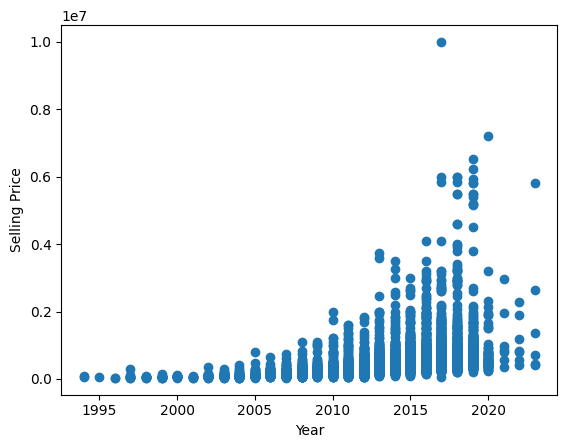

In [217]:
import matplotlib.pyplot as plt
plt.Figure(figsize=(6,6))
plt.scatter(df['year'], df['selling_price'])
plt.xlabel('Year')
plt.ylabel('Selling Price')
plt.show()

Positive corelation above

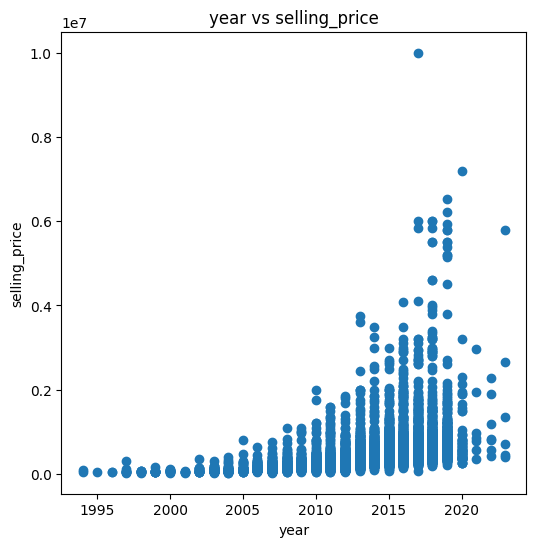

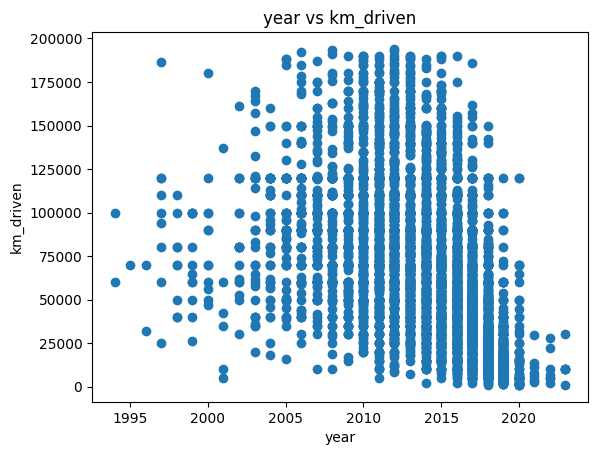

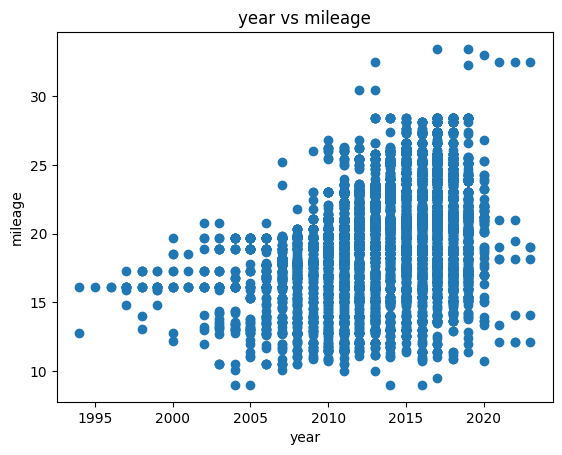

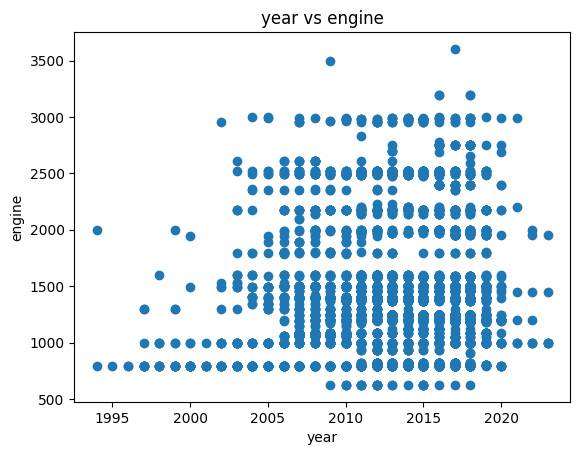

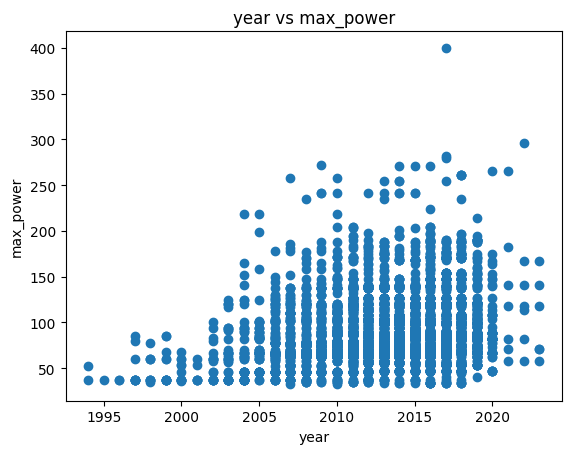

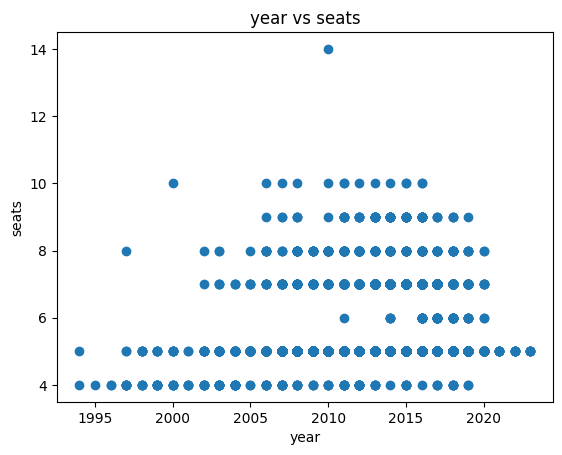

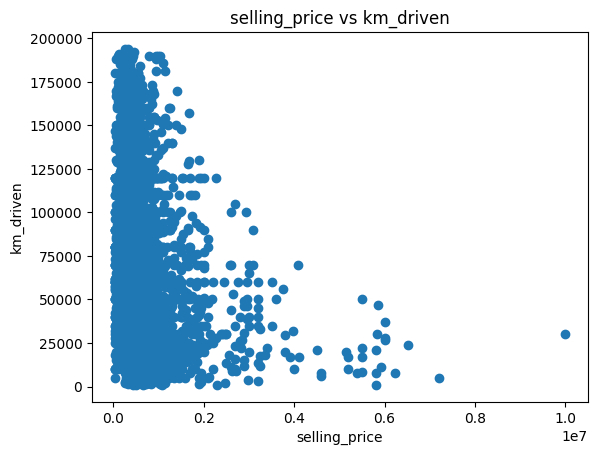

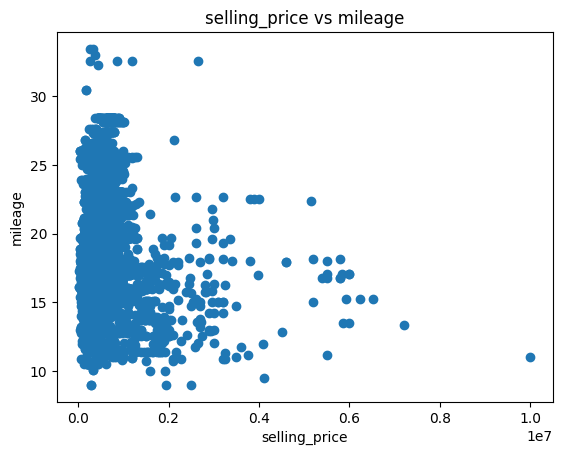

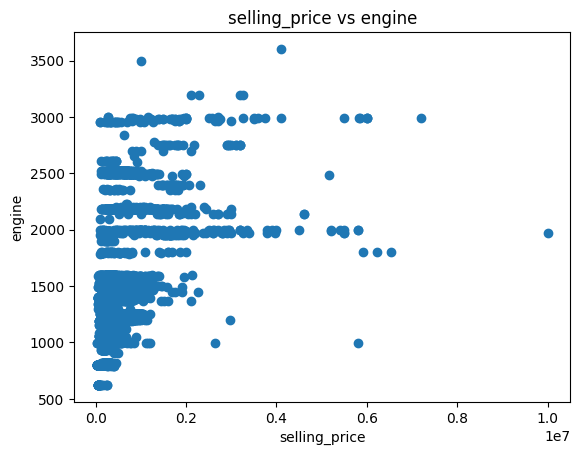

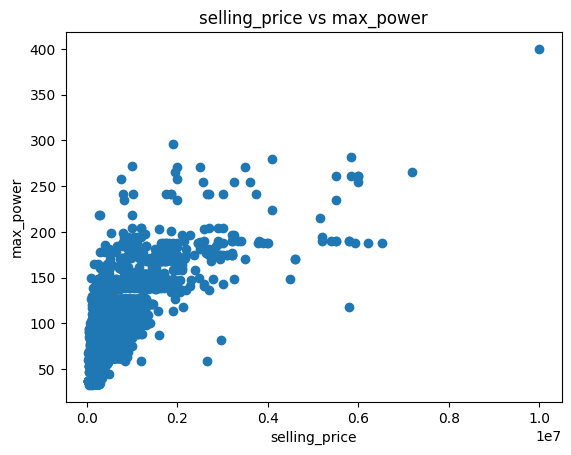

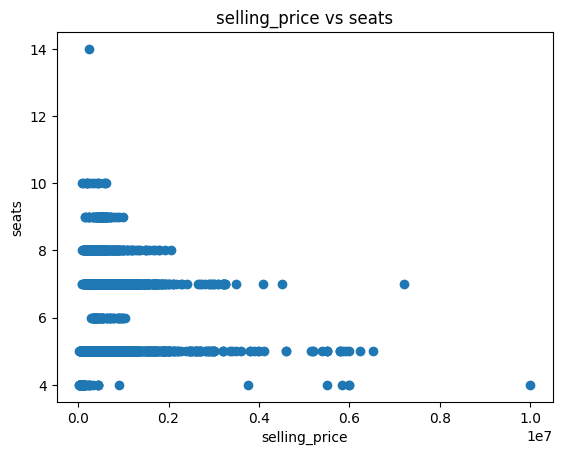

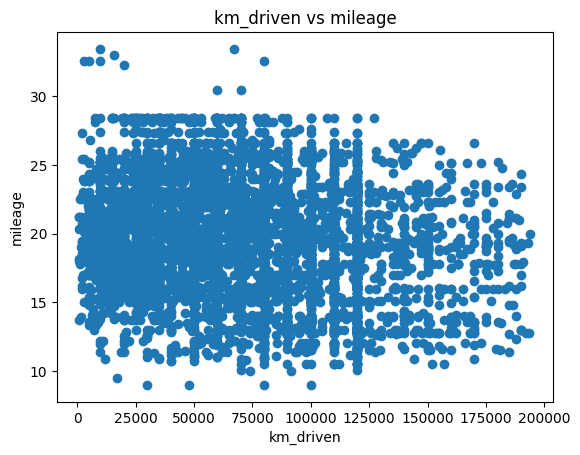

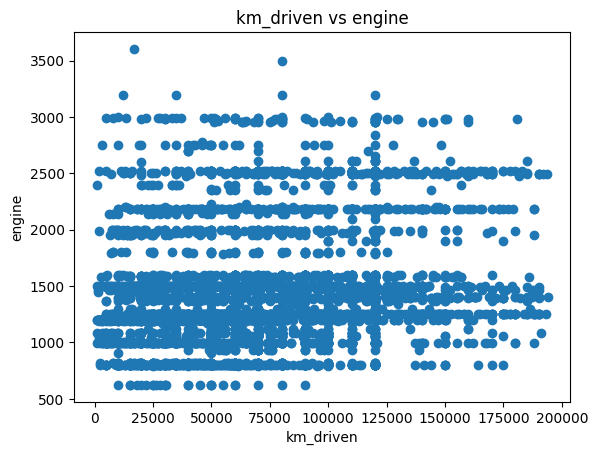

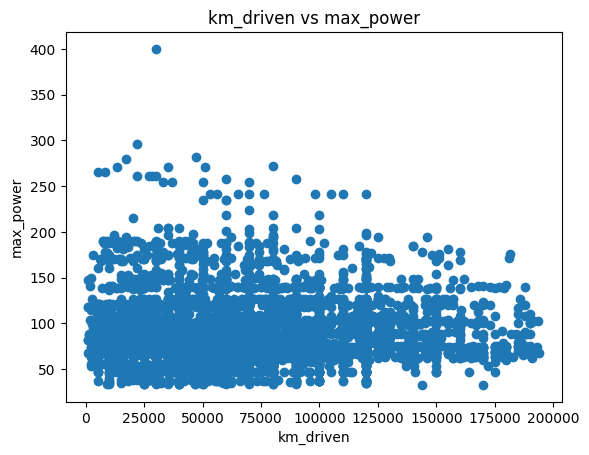

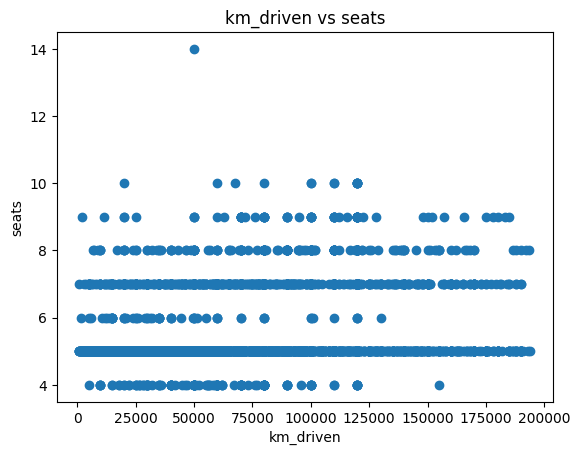

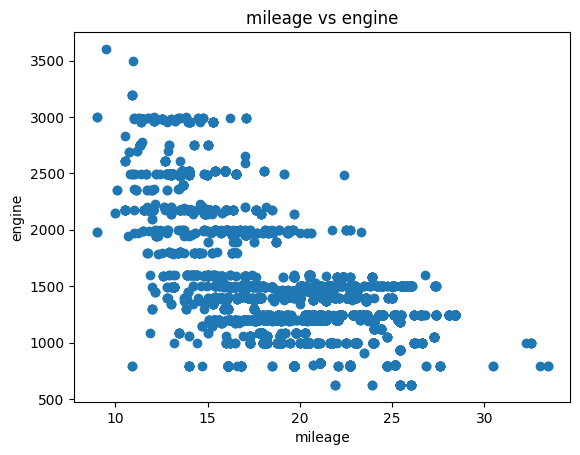

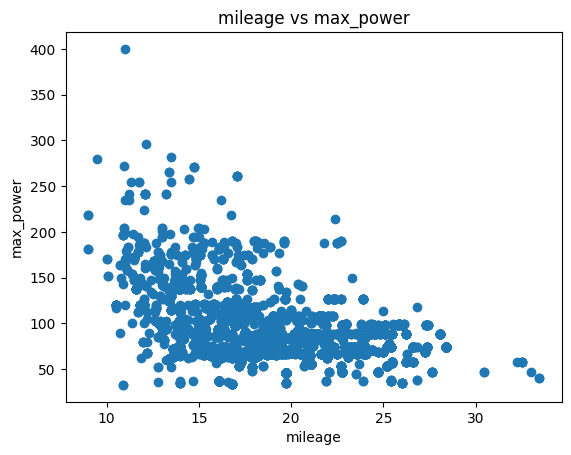

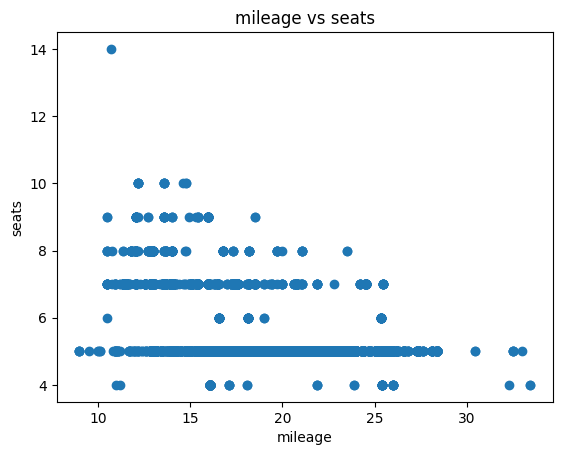

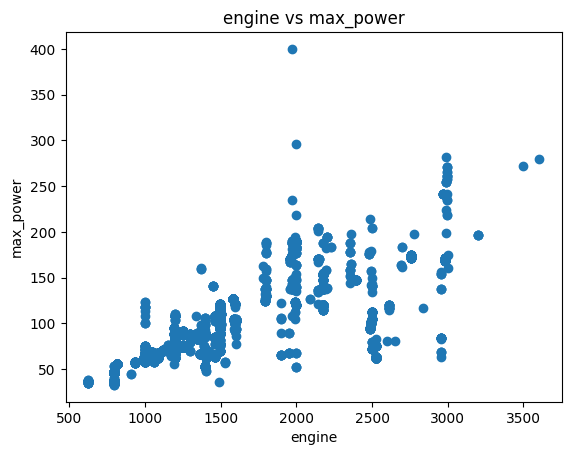

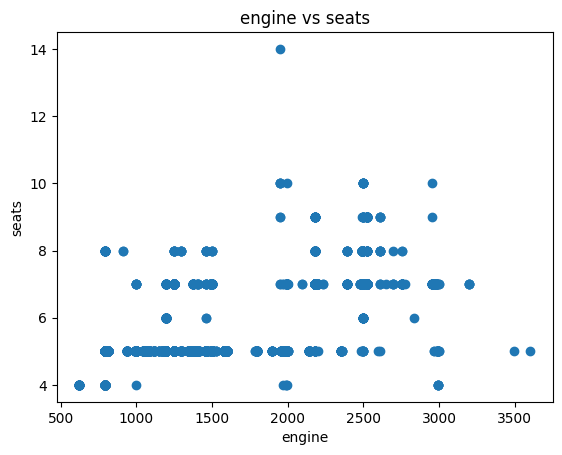

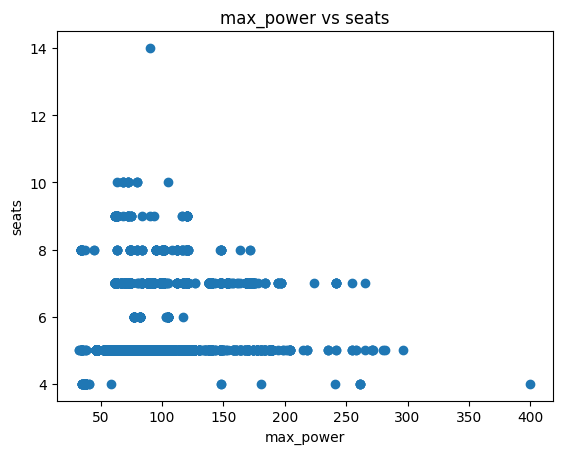

In [221]:
import matplotlib.pyplot as plt

columns = ['year', 'selling_price', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']

plt.figure(figsize=(6, 6))

for i in range(len(columns)):
    for j in range(i + 1, len(columns)):
        plt.scatter(df[columns[i]], df[columns[j]])
        plt.xlabel(columns[i])
        plt.ylabel(columns[j])
        plt.title(f'{columns[i]} vs {columns[j]}')
        plt.show()

Line Graph

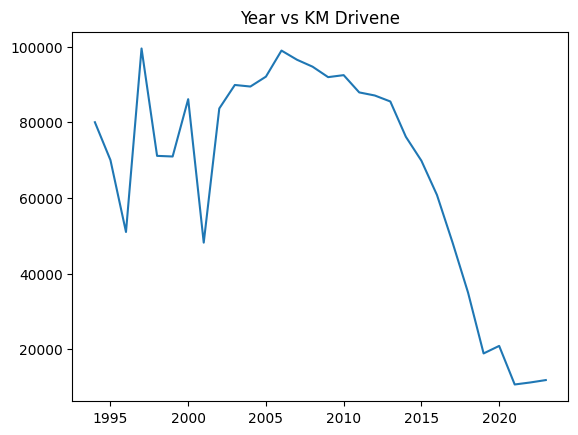

In [223]:
temp=df.groupby('year')['km_driven'].mean()
plt.plot(temp.index, temp)
plt.title('Year vs KM Drivene')
plt.show()

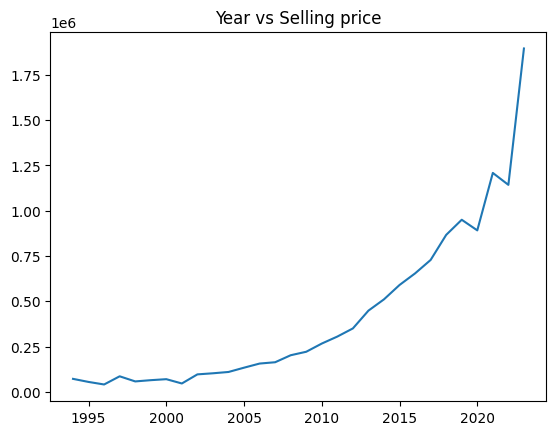

In [227]:
temp=df.groupby('year')['selling_price'].mean()
plt.Figure(figsize=(20,6))
plt.plot(temp.index, temp)
plt.title('Year vs Selling price')
plt.show()

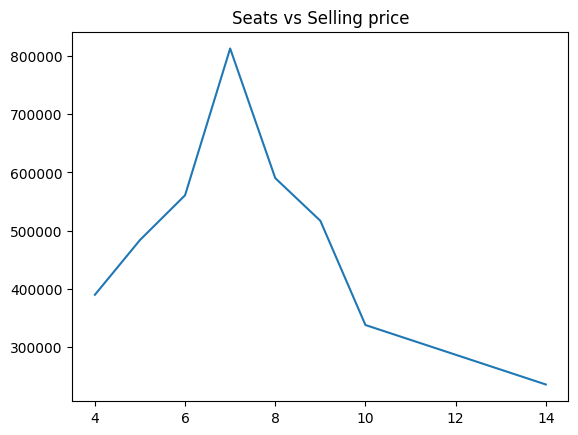

In [228]:
temp=df.groupby('seats')['selling_price'].mean()
plt.Figure(figsize=(20,6))
plt.plot(temp.index, temp)
plt.title('Seats vs Selling price')
plt.show()

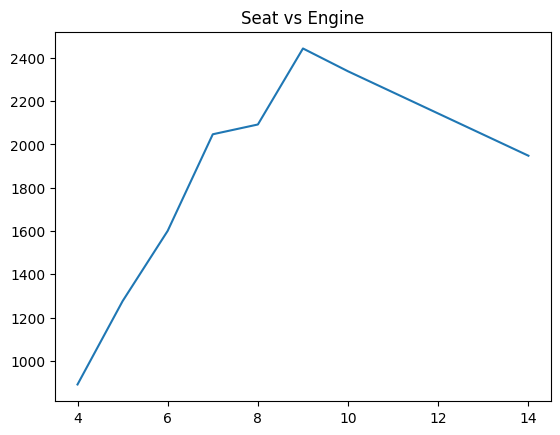

In [ ]:
temp=df.groupby('seats')['engine'].mean()
plt.Figure(figsize=(20,6))
plt.plot(temp.index, temp)
plt.title('Seat vs Engine')
plt.show()

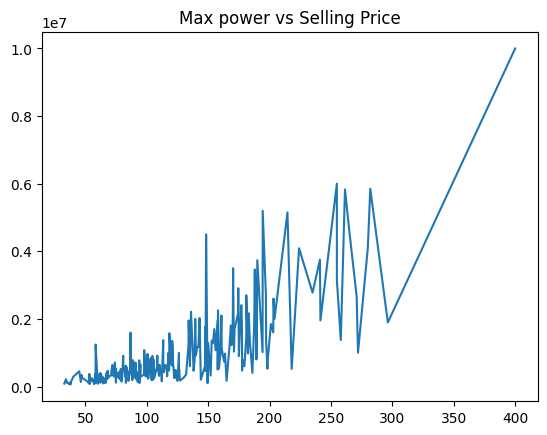

In [234]:
temp=df.groupby('max_power')['selling_price'].mean()
plt.Figure(figsize=(20,6))
plt.plot(temp.index, temp)
plt.title('Max power vs Selling Price')
plt.show()

HeatMap - Seaborn

<Axes: >

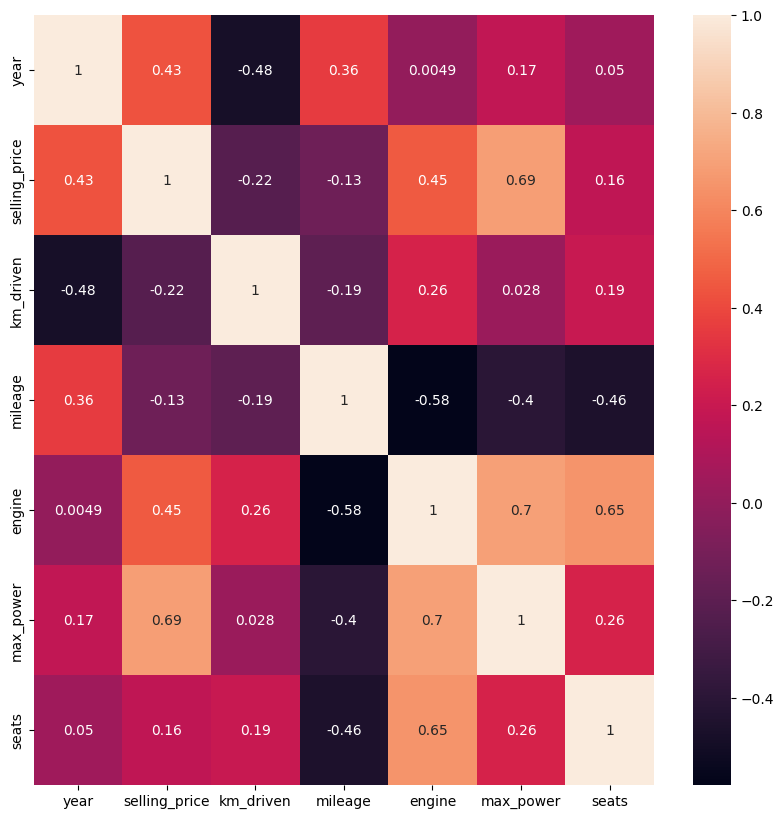

In [272]:
import seaborn as sns
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(numeric_only=True), annot=True)

Seaborn - Count plot

<Axes: xlabel='transmission', ylabel='count'>

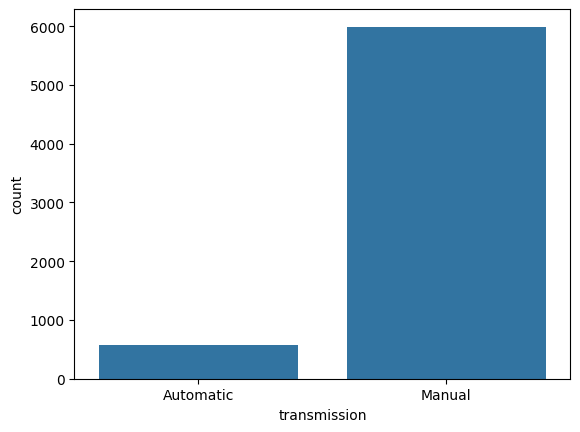

In [240]:
sns.countplot(x=df['transmission'])

<Axes: xlabel='transmission', ylabel='count'>

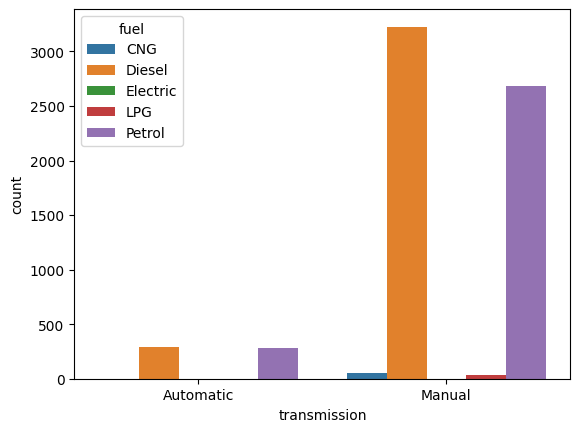

In [241]:
sns.countplot(x=df['transmission'], hue=df['fuel'])

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29],
 [Text(0, 0, 'Ambassador'),
  Text(1, 0, 'Audi'),
  Text(2, 0, 'BMW'),
  Text(3, 0, 'Chevrolet'),
  Text(4, 0, 'Daewoo'),
  Text(5, 0, 'Datsun'),
  Text(6, 0, 'Fiat'),
  Text(7, 0, 'Force'),
  Text(8, 0, 'Ford'),
  Text(9, 0, 'Honda'),
  Text(10, 0, 'Hyundai'),
  Text(11, 0, 'Isuzu'),
  Text(12, 0, 'Jaguar'),
  Text(13, 0, 'Jeep'),
  Text(14, 0, 'Kia'),
  Text(15, 0, 'Land'),
  Text(16, 0, 'Lexus'),
  Text(17, 0, 'MG'),
  Text(18, 0, 'Mahindra'),
  Text(19, 0, 'Maruti'),
  Text(20, 0, 'Mercedes-Benz'),
  Text(21, 0, 'Mitsubishi'),
  Text(22, 0, 'Nissan'),
  Text(23, 0, 'Opel'),
  Text(24, 0, 'Renault'),
  Text(25, 0, 'Skoda'),
  Text(26, 0, 'Tata'),
  Text(27, 0, 'Toyota'),
  Text(28, 0, 'Volkswagen'),
  Text(29, 0, 'Volvo')])

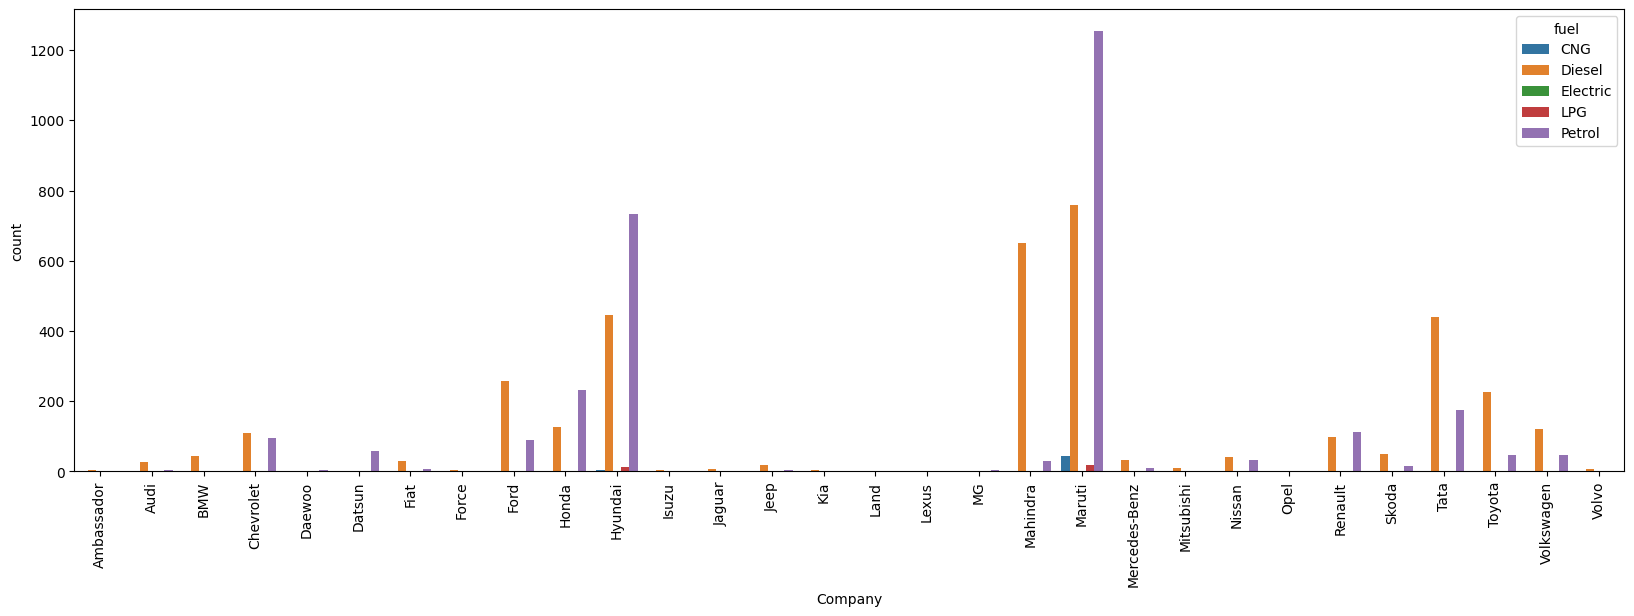

In [246]:
plt.figure(figsize=(20,6))
sns.countplot(x=df['Company'], hue=df['fuel'])
plt.xticks(rotation=90)

([<matplotlib.axis.XTick at 0x1dc47f43890>,
 [Text(1990, 0, '1990'),
  Text(1991, 0, '1991'),
  Text(1992, 0, '1992'),
  Text(1993, 0, '1993'),
  Text(1994, 0, '1994'),
  Text(1995, 0, '1995'),
  Text(1996, 0, '1996'),
  Text(1997, 0, '1997'),
  Text(1998, 0, '1998'),
  Text(1999, 0, '1999'),
  Text(2000, 0, '2000'),
  Text(2001, 0, '2001'),
  Text(2002, 0, '2002'),
  Text(2003, 0, '2003'),
  Text(2004, 0, '2004'),
  Text(2005, 0, '2005'),
  Text(2006, 0, '2006'),
  Text(2007, 0, '2007'),
  Text(2008, 0, '2008'),
  Text(2009, 0, '2009'),
  Text(2010, 0, '2010'),
  Text(2011, 0, '2011'),
  Text(2012, 0, '2012'),
  Text(2013, 0, '2013'),
  Text(2014, 0, '2014'),
  Text(2015, 0, '2015'),
  Text(2016, 0, '2016'),
  Text(2017, 0, '2017'),
  Text(2018, 0, '2018'),
  Text(2019, 0, '2019'),
  Text(2020, 0, '2020'),
  Text(2021, 0, '2021'),
  Text(2022, 0, '2022')])

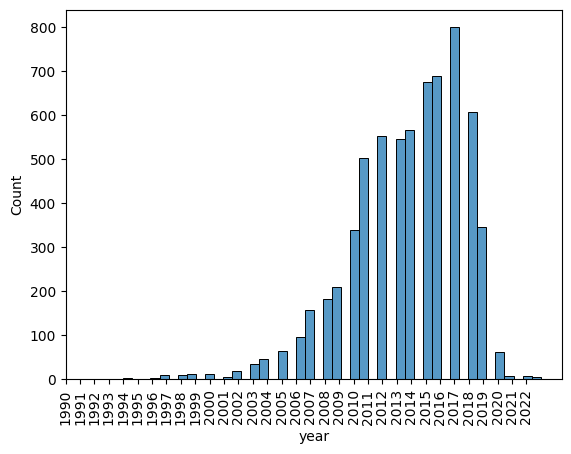

In [254]:
# plt.hist(df['year'])
sns.histplot(df['year'])
plt.xticks(range(1990, 2023, 1), rotation=90)

(array([-2000000.,        0.,  2000000.,  4000000.,  6000000.,  8000000.,
        10000000., 12000000.]),
 [Text(-2000000.0, 0, '−0.2'),
  Text(0.0, 0, '0.0'),
  Text(2000000.0, 0, '0.2'),
  Text(4000000.0, 0, '0.4'),
  Text(6000000.0, 0, '0.6'),
  Text(8000000.0, 0, '0.8'),
  Text(10000000.0, 0, '1.0'),
  Text(12000000.0, 0, '1.2')])

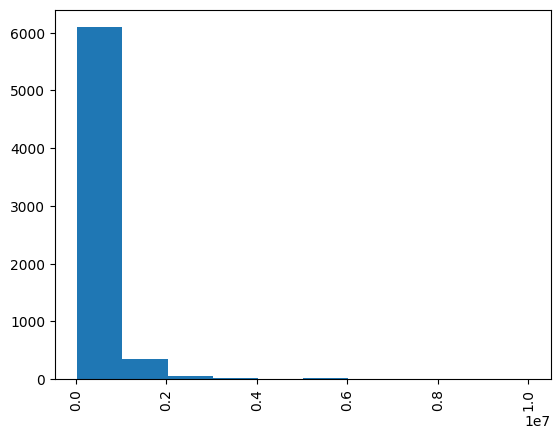

In [257]:
plt.hist(df['selling_price'])
plt.xticks(rotation=90)

In [263]:
a = df.groupby(['fuel', 'transmission'])['mileage'].agg(['mean', 'min', 'max', 'std', 'count']).round(2).sort_values('mean', ascending=False)
a[a['count']>20]

C:\Users\rijok\AppData\Local\Temp\ipykernel_2992\282712047.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  a = df.groupby(['fuel', 'transmission'])['mileage'].agg(['mean', 'min', 'max', 'std', 'count']).round(2).sort_values('mean', ascending=False)


,,mean,min,max,std,count
fuel,transmission,,,,,
CNG,Manual,24.29,11.88,33.44,5.07,50
Diesel,Manual,20.23,10.50,32.52,4.41,3227
Petrol,Manual,19.25,11.10,32.52,2.73,2679
LPG,Manual,18.35,10.90,26.20,5.05,34
Petrol,Automatic,17.88,9.00,24.04,3.61,278
Diesel,Automatic,16.69,9.00,28.40,4.37,294


In [264]:
a = df.groupby(['fuel', 'transmission'])['km_driven'].agg(['mean', 'min', 'max', 'std', 'count']).round(2).sort_values('mean', ascending=False)
a[a['count']>20]

C:\Users\rijok\AppData\Local\Temp\ipykernel_2992\508461133.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  a = df.groupby(['fuel', 'transmission'])['km_driven'].agg(['mean', 'min', 'max', 'std', 'count']).round(2).sort_values('mean', ascending=False)


mean      min       max       std  count
fuel   transmission                                              
Diesel Manual        84024.44   2000.0  194000.0  38910.90   3227
LPG    Manual        82646.59  30000.0  175000.0  33028.21     34
CNG    Manual        63784.11   5000.0  170000.0  35745.90     50
Diesel Automatic     58949.45   1000.0  185000.0  36485.99    294
Petrol Manual        54012.31   1000.0  191000.0  34360.51   2679
       Automatic     38414.87   1000.0  150000.0  30672.93    278

In [265]:
a = df.groupby(['fuel', 'transmission'])['selling_price'].agg(['mean', 'min', 'max', 'std', 'count']).round(2).sort_values('mean', ascending=False)
a[a['count']>20]

C:\Users\rijok\AppData\Local\Temp\ipykernel_2992\1291041639.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  a = df.groupby(['fuel', 'transmission'])['selling_price'].agg(['mean', 'min', 'max', 'std', 'count']).round(2).sort_values('mean', ascending=False)


,,mean,min,max,std,count
fuel,transmission,,,,,
Diesel,Automatic,1807282.29,245000.0,7200000.0,1316158.29,294
Petrol,Automatic,845050.33,75000.0,10000000.0,1012196.38,278
Diesel,Manual,552631.17,45000.0,3200000.0,327171.70,3227
Petrol,Manual,340619.63,29999.0,1520000.0,204721.27,2679
CNG,Manual,319619.94,120000.0,545000.0,102441.33,50
LPG,Manual,208264.71,54000.0,375000.0,79485.20,34


In [266]:
a = df.groupby(['engine_category', 'transmission'])['selling_price'].agg(['mean', 'min', 'max', 'std', 'count']).round(2).sort_values('mean', ascending=False)
a[a['count']>20]

C:\Users\rijok\AppData\Local\Temp\ipykernel_2992\2166768012.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  a = df.groupby(['engine_category', 'transmission'])['selling_price'].agg(['mean', 'min', 'max', 'std', 'count']).round(2).sort_values('mean', ascending=False)


,,mean,min,max,std,count
engine_category,transmission,,,,,
high_power,Automatic,1882249.18,140000,10000000,1457829.84,313
medium_power,Automatic,843767.66,110000,2275000,382080.45,99
high_power,Manual,662564.95,50000,3200000,424722.06,1154
low_power,Automatic,597751.53,75000,5800000,517610.86,161
medium_power,Manual,486114.25,45000,1594000,251835.93,2315
low_power,Manual,328825.20,29999,1197000,178430.85,2521


In [267]:
a = df.groupby(['Company', 'fuel'])['selling_price'].agg(['mean', 'min', 'max', 'std', 'count']).round(2).sort_values('mean', ascending=False)
a[a['count']>20]

C:\Users\rijok\AppData\Local\Temp\ipykernel_2992\972818989.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  a = df.groupby(['Company', 'fuel'])['selling_price'].agg(['mean', 'min', 'max', 'std', 'count']).round(2).sort_values('mean', ascending=False)


,,mean,min,max,std,count
Company,fuel,,,,,
BMW,Diesel,2943295.45,480000.0,7200000.0,1944716.74,44
Mercedes-Benz,Diesel,2424666.67,515000.0,6000000.0,1369524.66,33
Audi,Diesel,2135148.07,810000.0,3975000.0,720022.62,27
Toyota,Diesel,1081224.61,245000.0,3500000.0,684201.74,227
Honda,Diesel,668574.76,250000.0,2125000.0,243392.53,127
Toyota,Petrol,668489.32,135000.0,2100000.0,520462.46,47
Mahindra,Diesel,645241.50,120000.0,2275000.0,320947.73,650
Skoda,Diesel,606019.98,110000.0,3251000.0,635570.00,50
Hyundai,Diesel,593293.02,100000.0,1950000.0,285310.44,447


In [268]:
a = df.groupby(['Company', 'fuel', 'transmission'])['selling_price'].agg(['mean', 'min', 'max', 'std', 'count']).round(2).sort_values('mean', ascending=False)
a[a['count']>20]

C:\Users\rijok\AppData\Local\Temp\ipykernel_2992\3778231560.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  a = df.groupby(['Company', 'fuel', 'transmission'])['selling_price'].agg(['mean', 'min', 'max', 'std', 'count']).round(2).sort_values('mean', ascending=False)


mean        min        max  \
Company       fuel   transmission                                     
BMW           Diesel Automatic     2943295.45   480000.0  7200000.0   
Mercedes-Benz Diesel Automatic     2408250.00   515000.0  6000000.0   
Audi          Diesel Automatic     2135148.07   810000.0  3975000.0   
Toyota        Diesel Automatic     2096437.50  1225000.0  3500000.0   
Hyundai       Diesel Automatic     1007719.96   245000.0  1950000.0   
Toyota        Diesel Manual         914625.57   245000.0  3200000.0   
Mahindra      Diesel Automatic      880459.38   365000.0  2275000.0   
Honda         Petrol Automatic      778408.14   110000.0  2000000.0   
              Diesel Manual         668325.36   250000.0  2125000.0   
Hyundai       Petrol Automatic      658550.00   140000.0  2975000.0   
Mahindra      Diesel Manual         631044.01   120000.0  1800000.0   
Hyundai       Diesel Manual         568741.66   100000.0  1300000.0   
Renault       Diesel Manual         552074.41   220000.0  1265000.0   
Maruti        Diesel Manual         549375.63    70000.0  1200000.0   
              Petrol Automatic      522638.52    75000.0  1025000.0   
Nissan        Diesel Manual         498024.90   204999.0  1200000.0   
Mahindra      Petrol Manual         480500.00   135000.0  1132000.0   
Ford          Diesel Manual         469641.08    90000.0  1145000.0   
Volkswagen    Petrol Manual         466511.63   210000.0   808000.0   
Honda         Petrol Manual         457193.09    50000.0  1180000.0   
Ford          Petrol Manual         456166.64   100000.0   910000.0   
Toyota        Petrol Manual         450906.22   135000.0  1400000.0   
Volkswagen    Diesel Manual         439123.78   225000.0  1350000.0   
Skoda         Diesel Manual         411666.64   110000.0  1100000.0   
Nissan        Petrol Manual         405458.33   110000.0   950000.0   
Hyundai       Petrol Manual         385823.88    55000.0  1405000.0   
Tata          Petrol Manual         354674.64    45000.0   919999.0   
Renault       Petrol Manual         349480.36   200000.0   800000.0   
Fiat          Diesel Manual         341774.13   170000.0   700000.0   
Tata          Diesel Manual         337539.16    45000.0  1700000.0   
Maruti        CNG    Manual         335244.38   150000.0   545000.0   
Chevrolet     Diesel Manual         323067.29   120000.0   900000.0   
Datsun        Petrol Manual         316749.95   150000.0   590000.0   
Maruti        Petrol Manual         287110.14    29999.0  1040000.0   
Chevrolet     Petrol Manual         173784.46    45000.0   550000.0   

                                          std  count  
Company       fuel   transmission                     
BMW           Diesel Automatic     1944716.74     44  
Mercedes-Benz Diesel Automatic     1388135.56     32  
Audi          Diesel Automatic      720022.62     27  
Toyota        Diesel Automatic      665309.77     32  
Hyundai       Diesel Automatic      438108.25     25  
Toyota        Diesel Manual         526037.44    195  
Mahindra      Diesel Automatic      389336.75     37  
Honda         Petrol Automatic      434339.60     49  
              Diesel Manual         244347.87    126  
Hyundai       Petrol Automatic      444672.17     60  
Mahindra      Diesel Manual         311081.20    613  
Hyundai       Diesel Manual         253950.59    422  
Renault       Diesel Manual         193505.66     94  
Maruti        Diesel Manual         207093.60    740  
              Petrol Automatic      186484.99     83  
Nissan        Diesel Manual         237042.71     40  
Mahindra      Petrol Manual         250490.66     30  
Ford          Diesel Manual         262876.08    248  
Volkswagen    Petrol Manual         140400.51     43  
Honda         Petrol Manual         232499.13    182  
Ford          Petrol Manual         221847.35     84  
Toyota        Petrol Manual         304880.98     32  
Volkswagen    Diesel Manual         177569.71    105  
Skoda         Diesel Manual         24

In [269]:
df.dtypes

Name                  object
Company             category
year                   int64
selling_price          int64
price_category      category
km_driven            float64
fuel                category
seller_type         category
transmission        category
owner               category
mileage              float64
mileage_category    category
engine               float64
engine_category     category
max_power            float64
torque                object
seats                float64
dtype: object

In [271]:
a = df.groupby(['fuel', 'price_category', 'max_power'])['selling_price'].agg(['mean', 'min', 'max', 'std', 'count']).round(2).sort_values('mean', ascending=False)
a[a['count']>20]

C:\Users\rijok\AppData\Local\Temp\ipykernel_2992\2958944918.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  a = df.groupby(['fuel', 'price_category', 'max_power'])['selling_price'].agg(['mean', 'min', 'max', 'std', 'count']).round(2).sort_values('mean', ascending=False)


mean        min        max        std  \
fuel   price_category max_power                                                
Diesel Luxury         170.0      1901653.81  1325000.0  4600000.0  852688.09   
       Premium        126.2       998317.40   750000.0  1300000.0  146850.41   
Petrol Premium        121.3       966115.38   700000.0  1270000.0  162195.03   
Diesel Premium        100.6       953999.91   680000.0  1300000.0  157400.54   
                      120.0       937265.31   670000.0  1300000.0  164024.36   
...                                     ...        ...        ...        ...   
Petrol Cheap          67.0        159319.09    80000.0   250000.0   50542.33   
                      46.3        133355.46    45957.0   225000.0   37400.38   
                      62.0        119666.59    45000.0   190000.0   36795.70   
                      60.0         80500.00    30000.0   200000.0   37566.21   
                      37.0         66759.78    29999.0   157000.0   32275.50   

                                 count  
fuel   price_category max_power         
Diesel Luxury         170.0         26  
       Premium        126.2         63  
Petrol Premium        121.3         26  
Diesel Premium        100.6         44  
                      120.0         49  
...                                ...  
Petrol Cheap          67.0          47  
                      46.3         156  
                      62.0          27  
                      60.0          26  
                      37.0          87  

[83 rows x 5 columns]